## 0-A. Install Dependencies & Mount Google Drive
> **Run this cell first.**  
> It will open a browser popup asking you to authorise Drive access — sign in with your Google account.


In [ ]:
# Install any missing packages (geopandas etc. may need this on Colab)
import subprocess, sys
pkgs = ["geopandas", "shapely", "pyproj", "fiona"]
for pkg in pkgs:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
print("All packages ready ✓")


All packages ready ✓


In [ ]:
# ── Mount Google Drive ─────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive mounted ✓")


Mounted at /content/drive
Google Drive mounted ✓


## 1. Imports

In [ ]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib.patches import PathPatch, FancyArrowPatch
from matplotlib.path import Path as MplPath
import geopandas as gpd
import shapely.ops as sops
from scipy import stats
from scipy.stats import (norm, expon, uniform, bernoulli, binom, poisson,
                         gumbel_r, genextreme, lognorm, kstest)

warnings.filterwarnings("ignore")
print("All imports successful ✓")


All imports successful ✓


## 2. Configuration

In [ ]:
# ── CONFIG ─────────────────────────────────────────────────────────────────────
# ⬇️  CHANGE ONLY THIS BLOCK to match your Google Drive folder structure
# ---------------------------------------------------------------------------
# Path inside your Drive where all {year}_data.csv files live, e.g.:
#   MyDrive/PM2.5/  or  MyDrive/Workshop/NWH/PM2.5/
DRIVE_DATA_DIR = "/content/drive/MyDrive/NPTEL/data/PM_2.5"

# Path to your shapefile (.shp) — can be the same folder or a sub-folder
DRIVE_SHP_DIR  = "/content/drive/MyDrive/NPTEL/India Shapefile With Kashmir"   # searched recursively

# ---------------------------------------------------------------------------

import os, glob

DATA_DIR = DRIVE_DATA_DIR
OUT_DIR  = DRIVE_DATA_DIR   # plots will be saved back to the same Drive folder

# Create output dir if it doesn't exist
os.makedirs(OUT_DIR, exist_ok=True)

YEARS                = list(range(2010, 2025))
THRESHOLD_PERCENTILE = 75          # "high PM2.5" = above 75th percentile

# Auto-locate shapefile
SHP_PATH = glob.glob(os.path.join(DRIVE_SHP_DIR, "**/*.shp"), recursive=True)
if not SHP_PATH:
    SHP_PATH = glob.glob(os.path.join(DRIVE_SHP_DIR, "*.shp"))
SHP_PATH = SHP_PATH[0] if SHP_PATH else None

COLORS  = {"primary":"#2E4057","accent":"#C84B31","soft":"#A8DADC","gold":"#E9C46A","green":"#2A9D8F"}
SCALE   = 1e9          # convert raw kg/kg-like units → µg/m³
UNIT    = "µg/m³"
MONTHS  = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

print(f"DATA_DIR : {DATA_DIR}")
print(f"OUT_DIR  : {OUT_DIR}")
print(f"SHP_PATH : {SHP_PATH if SHP_PATH else '⚠️  NOT FOUND — maps will skip boundary clipping'}")


DATA_DIR : /content/drive/MyDrive/NPTEL/data/PM_2.5
OUT_DIR  : /content/drive/MyDrive/NPTEL/data/PM_2.5
SHP_PATH : /content/drive/MyDrive/NPTEL/India Shapefile With Kashmir/New folder/New_3states.shp


## 3. Load Data

In [ ]:
print("Loading CSV files …")
annual_frames  = {}
monthly_frames = {}

for yr in YEARS:
    fpath = os.path.join(DATA_DIR, f"{yr}_data.csv")
    if not os.path.exists(fpath):
        continue
    df = pd.read_csv(fpath)
    print(df)

    all_cols = sorted([c for c in df.columns if c not in ("lat","lon")])[:12]
    n_months = len(all_cols)
    df[all_cols] = df[all_cols].astype(float) * SCALE
    df["annual_mean"] = df[all_cols].mean(axis=1)
    annual_frames[yr] = df[["lat","lon","annual_mean"]].copy()
    rename_map = {old_col: MONTHS[i] for i, old_col in enumerate(all_cols)}
    monthly_frames[yr] = df[["lat","lon"]+all_cols].rename(columns=rename_map).copy()
    print(f"  ✓ {yr}  ({n_months} months, scaled x1e9 to {UNIT})")

year_list  = sorted(annual_frames.keys())
coords     = annual_frames[year_list[0]][["lat","lon"]].reset_index(drop=True)
n_years    = len(year_list)
Y_matrix   = np.full((len(coords), n_years), np.nan)
for j, yr in enumerate(year_list):
    merged = coords.merge(annual_frames[yr], on=["lat","lon"], how="left")
    Y_matrix[:, j] = merged["annual_mean"].values


Loading CSV files …
      lat     lon       2010-01       2010-02       2010-03       2010-04  \
0    29.0  72.500  1.560905e-08  2.798957e-08  4.731708e-08  7.292935e-08   
1    29.0  73.125  1.538724e-08  3.070558e-08  4.112770e-08  6.539606e-08   
2    29.0  73.750  1.507587e-08  3.112317e-08  3.648153e-08  5.840581e-08   
3    29.0  74.375  1.455042e-08  2.711633e-08  3.262504e-08  5.052425e-08   
4    29.0  75.000  1.401091e-08  2.428663e-08  2.992320e-08  4.387790e-08   
..    ...     ...           ...           ...           ...           ...   
250  37.0  78.750  2.502684e-08  2.816101e-08  4.981543e-08  5.743671e-08   
251  37.0  79.375  4.544064e-08  4.348398e-08  7.384487e-08  7.594269e-08   
252  37.0  80.000  5.838322e-08  5.406361e-08  9.244879e-08  8.921840e-08   
253  37.0  80.625  7.885688e-08  6.613625e-08  1.175025e-07  1.075697e-07   
254  37.0  81.250  9.777279e-08  8.010024e-08  1.450714e-07  1.127710e-07   

          2010-05       2010-06       2010-07       201

## 4. NWH Clip & Data Summary

In [ ]:
# NWH clip
# nwh must be a valid GeoDataFrame (not None)
nwh = gpd.read_file("/content/drive/MyDrive/NPTEL/India Shapefile With Kashmir/India Shape/india_st.shp")

if nwh.crs is None:
    nwh = nwh.set_crs("EPSG:4326")   # assign CRS (no reprojection)
else:
    nwh = nwh.to_crs("EPSG:4326")    # reproject to EPSG:4326

# create point GeoDataFrame
result_gdf = gpd.GeoDataFrame(
    coords,
    geometry=gpd.points_from_xy(coords["lon"], coords["lat"]),
    crs="EPSG:4326"
)

# clip points inside NWH boundary
clipped = gpd.clip(result_gdf, nwh)
keep_idx = clipped.index.tolist()

# extract clipped data
Y_clip = Y_matrix[keep_idx, :]
coords_clip = coords.iloc[keep_idx].reset_index(drop=True)

print(f"NWH grid points: {len(keep_idx)}")

# Flat array of all annual mean PM2.5 values
data_flat = Y_clip.flatten()
data_flat = data_flat[~np.isnan(data_flat)]

# Regional annual mean per year
nwh_annual = np.nanmean(Y_clip, axis=0)

# Monthly climatology
monthly_means_per_month = []
for yr in year_list:
    df = monthly_frames[yr]
    merged = coords_clip.merge(df, on=["lat","lon"], how="left")
    row = []
    for m in MONTHS:
        if m in merged.columns:
            row.append(merged[m].astype(float).mean())
        else:
            row.append(np.nan)
    monthly_means_per_month.append(row)
monthly_arr  = np.array(monthly_means_per_month, dtype=float)
monthly_flat = monthly_arr.flatten()
monthly_flat = monthly_flat[~np.isnan(monthly_flat)]

# Seasonal subsets
winter_vals = monthly_arr[:, [0,1,10,11]].flatten()
summer_vals = monthly_arr[:, [5,6,7]].flatten()
winter_vals = winter_vals[~np.isnan(winter_vals)]
summer_vals = summer_vals[~np.isnan(summer_vals)]

threshold = np.percentile(data_flat, THRESHOLD_PERCENTILE)
p_exceed  = np.mean(data_flat > threshold)

print(f"\nData stats ({UNIT}): n={len(data_flat)}, mean={data_flat.mean():.2f}, std={data_flat.std():.2f}")
print(f"Threshold (75th pct): {threshold:.2f} {UNIT},  P(exceed)={p_exceed:.3f}")


NWH grid points: 140

Data stats (µg/m³): n=2100, mean=14.84, std=10.27
Threshold (75th pct): 21.18 µg/m³,  P(exceed)=0.250


## 5. Helper: NWH Map Function

In [ ]:
def make_nwh_map(ax, values, cmap="YlOrRd", title="", cbar_label="", nwh=None, norm_obj=None):
    lons_u = np.sort(coords_clip["lon"].unique())
    lats_u = np.sort(coords_clip["lat"].unique())[::-1]
    dlon   = np.diff(lons_u).min() if len(lons_u)>1 else 0.625
    dlat   = np.diff(np.sort(coords_clip["lat"].unique())).min() if len(lats_u)>1 else 0.5
    grid   = np.full((len(lats_u), len(lons_u)), np.nan)
    lon_idx = {v:i for i,v in enumerate(lons_u)}
    lat_idx = {v:i for i,v in enumerate(lats_u)}
    for i, (lat, lon) in enumerate(zip(coords_clip["lat"], coords_clip["lon"])):
        r, c = lat_idx.get(lat), lon_idx.get(lon)
        if r is not None and c is not None and i < len(values):
            grid[r, c] = values[i]
    lon_e = np.append(lons_u - dlon/2, lons_u[-1]+dlon/2)
    lat_s = np.sort(coords_clip["lat"].unique())
    lat_e = np.append(lat_s - dlat/2, lat_s[-1]+dlat/2)[::-1]
    kwargs = dict(cmap=cmap, shading="flat", zorder=2)
    if norm_obj: kwargs["norm"] = norm_obj
    m = ax.pcolormesh(lon_e, lat_e, grid, **kwargs)
    if nwh is not None:
        union = sops.unary_union(nwh.geometry)
        geoms = [union] if union.geom_type=="Polygon" else list(union.geoms)
        verts, codes = [], []
        for g in geoms:
            ext = np.array(g.exterior.coords)
            verts.append(ext)
            codes.append([MplPath.MOVETO]+[MplPath.LINETO]*(len(ext)-2)+[MplPath.CLOSEPOLY])
        path  = MplPath(np.concatenate(verts), np.concatenate(codes))
        patch = PathPatch(path, transform=ax.transData)
        m.set_clip_path(patch)
        nwh.boundary.plot(ax=ax, color="black", linewidth=0.8, zorder=3)
    ax.set_title(title, fontsize=9, fontweight="bold")
    ax.set_xlabel("Lon (°E)", fontsize=7); ax.set_ylabel("Lat (°N)", fontsize=7)
    ax.tick_params(labelsize=6)
    return m

print("Helper function defined ✓")


Helper function defined ✓


## Slide 2 — Geometry of Data: Overlapping KDE Distributions

Plotting Slide 2: Geometry of Data …


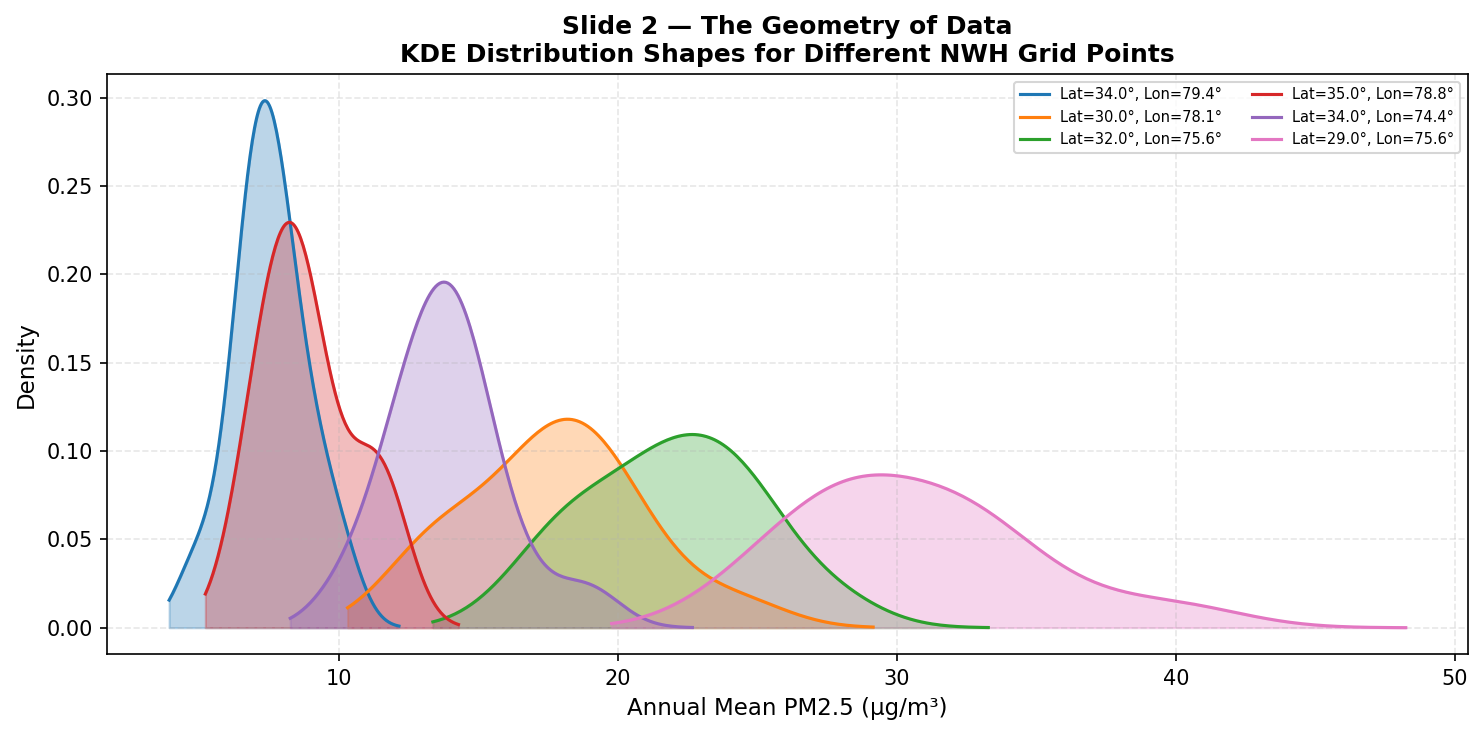

  ✅ Slide 2 saved


In [ ]:
print("Plotting Slide 2: Geometry of Data …")
fig, ax = plt.subplots(figsize=(10,5), dpi=150)
np.random.seed(42)
sample_pts = np.random.choice(len(coords_clip), min(6, len(coords_clip)), replace=False)
cmap6 = plt.cm.tab10(np.linspace(0,0.6,len(sample_pts)))
for idx, (i, col) in enumerate(zip(sample_pts, cmap6)):
    yi = Y_clip[i, :]
    yi = yi[~np.isnan(yi)]
    if len(yi) < 4: continue
    kde = stats.gaussian_kde(yi)
    xs  = np.linspace(yi.min()*0.8, yi.max()*1.2, 200)
    ax.fill_between(xs, kde(xs), alpha=0.3, color=col)
    ax.plot(xs, kde(xs), color=col, linewidth=1.5,
            label=f"Lat={coords_clip['lat'].iloc[i]:.1f}°, Lon={coords_clip['lon'].iloc[i]:.1f}°")
ax.set_xlabel("Annual Mean PM2.5 (µg/m³)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Slide 2 — The Geometry of Data\nKDE Distribution Shapes for Different NWH Grid Points",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=7, ncol=2)
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR,"Slide02_Geometry_of_Data.png"), dpi=150, bbox_inches="tight")
plt.show()
print("  ✅ Slide 2 saved")


## Slide 3 — Raw Data vs Probability

Plotting Slide 3: Raw Data vs Probability …


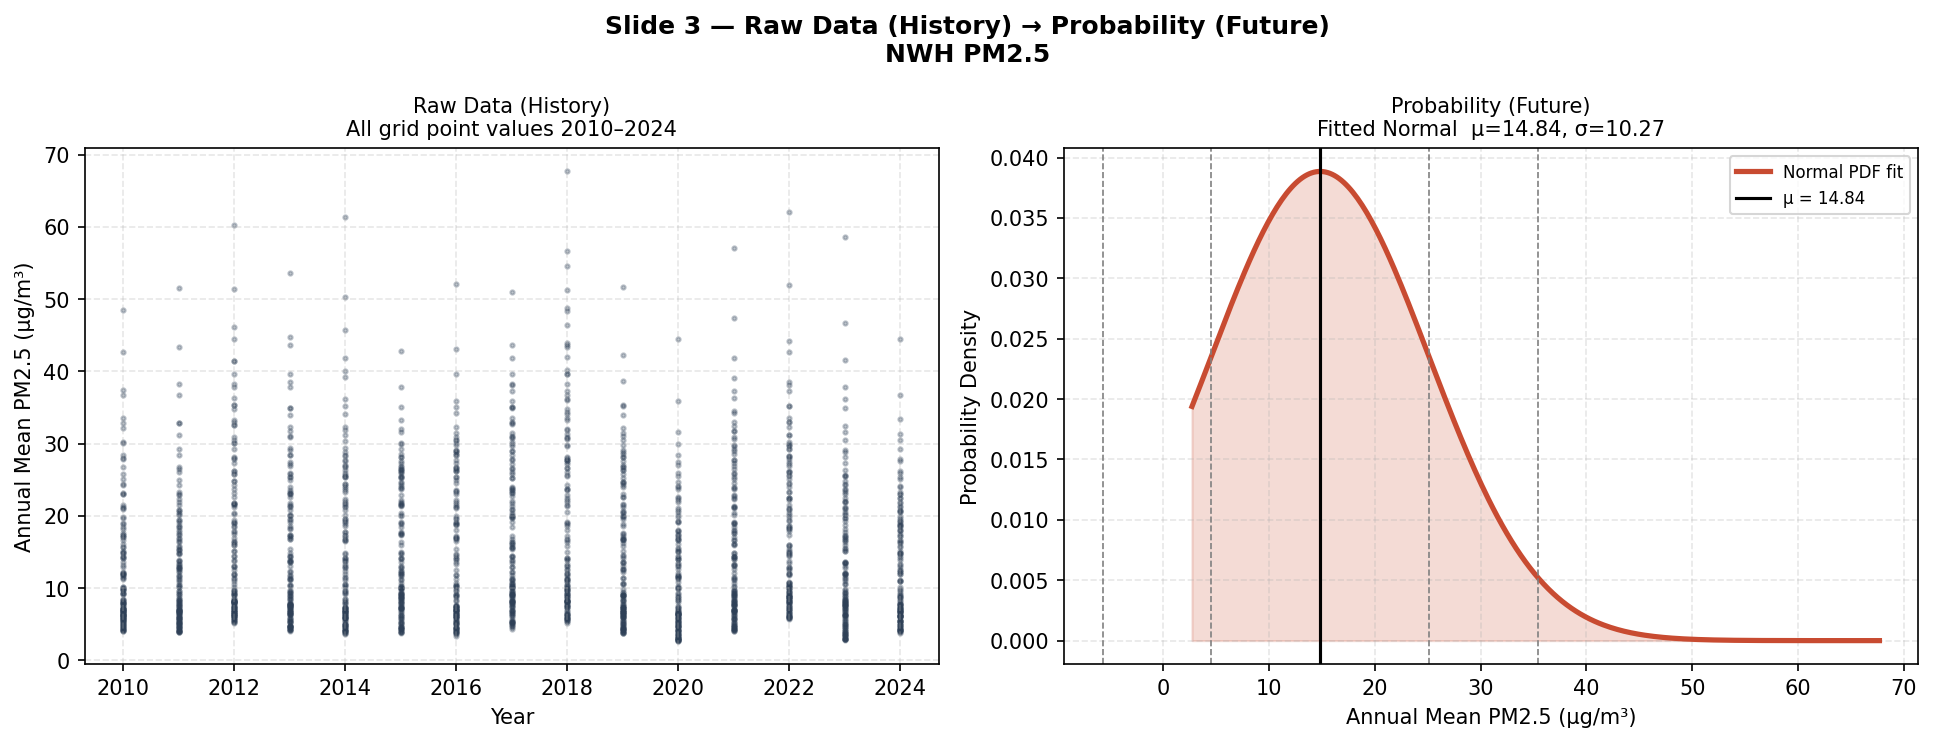

  ✅ Slide 3 saved


In [ ]:
print("Plotting Slide 3: Raw Data vs Probability …")
fig, axes = plt.subplots(1, 2, figsize=(13,5), dpi=150)
fig.suptitle("Slide 3 — Raw Data (History) → Probability (Future)\nNWH PM2.5",
             fontsize=12, fontweight="bold")

ax = axes[0]
pts = np.random.choice(len(coords_clip), min(300, len(coords_clip)), replace=False)
for i in pts:
    yi = Y_clip[i,:]
    ax.scatter(year_list, yi, s=4, alpha=0.3, color=COLORS["primary"])
ax.set_xlabel("Year", fontsize=10); ax.set_ylabel("Annual Mean PM2.5 (µg/m³)", fontsize=10)
ax.set_title("Raw Data (History)\nAll grid point values 2010–2024", fontsize=10)
ax.grid(True, linestyle="--", alpha=0.3)

ax = axes[1]
mu, sigma = norm.fit(data_flat)
xs = np.linspace(data_flat.min(), data_flat.max(), 300)
ax.plot(xs, norm.pdf(xs, mu, sigma), color=COLORS["accent"], linewidth=2.5, label="Normal PDF fit")
ax.fill_between(xs, norm.pdf(xs, mu, sigma), alpha=0.2, color=COLORS["accent"])
for s, alpha in [(1,0.4),(2,0.2)]:
    ax.axvline(mu+s*sigma, color="grey", linestyle="--", linewidth=0.8)
    ax.axvline(mu-s*sigma, color="grey", linestyle="--", linewidth=0.8)
ax.axvline(mu, color="black", linewidth=1.5, label=f"μ = {mu:.2f}")
ax.set_xlabel("Annual Mean PM2.5 (µg/m³)", fontsize=10); ax.set_ylabel("Probability Density", fontsize=10)
ax.set_title(f"Probability (Future)\nFitted Normal  μ={mu:.2f}, σ={sigma:.2f}", fontsize=10)
ax.legend(fontsize=8); ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR,"Slide03_Raw_vs_Probability.png"), dpi=150, bbox_inches="tight")
plt.show()
print("  ✅ Slide 3 saved")


## Slide 8 — 6 Distribution Types

Plotting Slide 8: 6 Distribution Types …


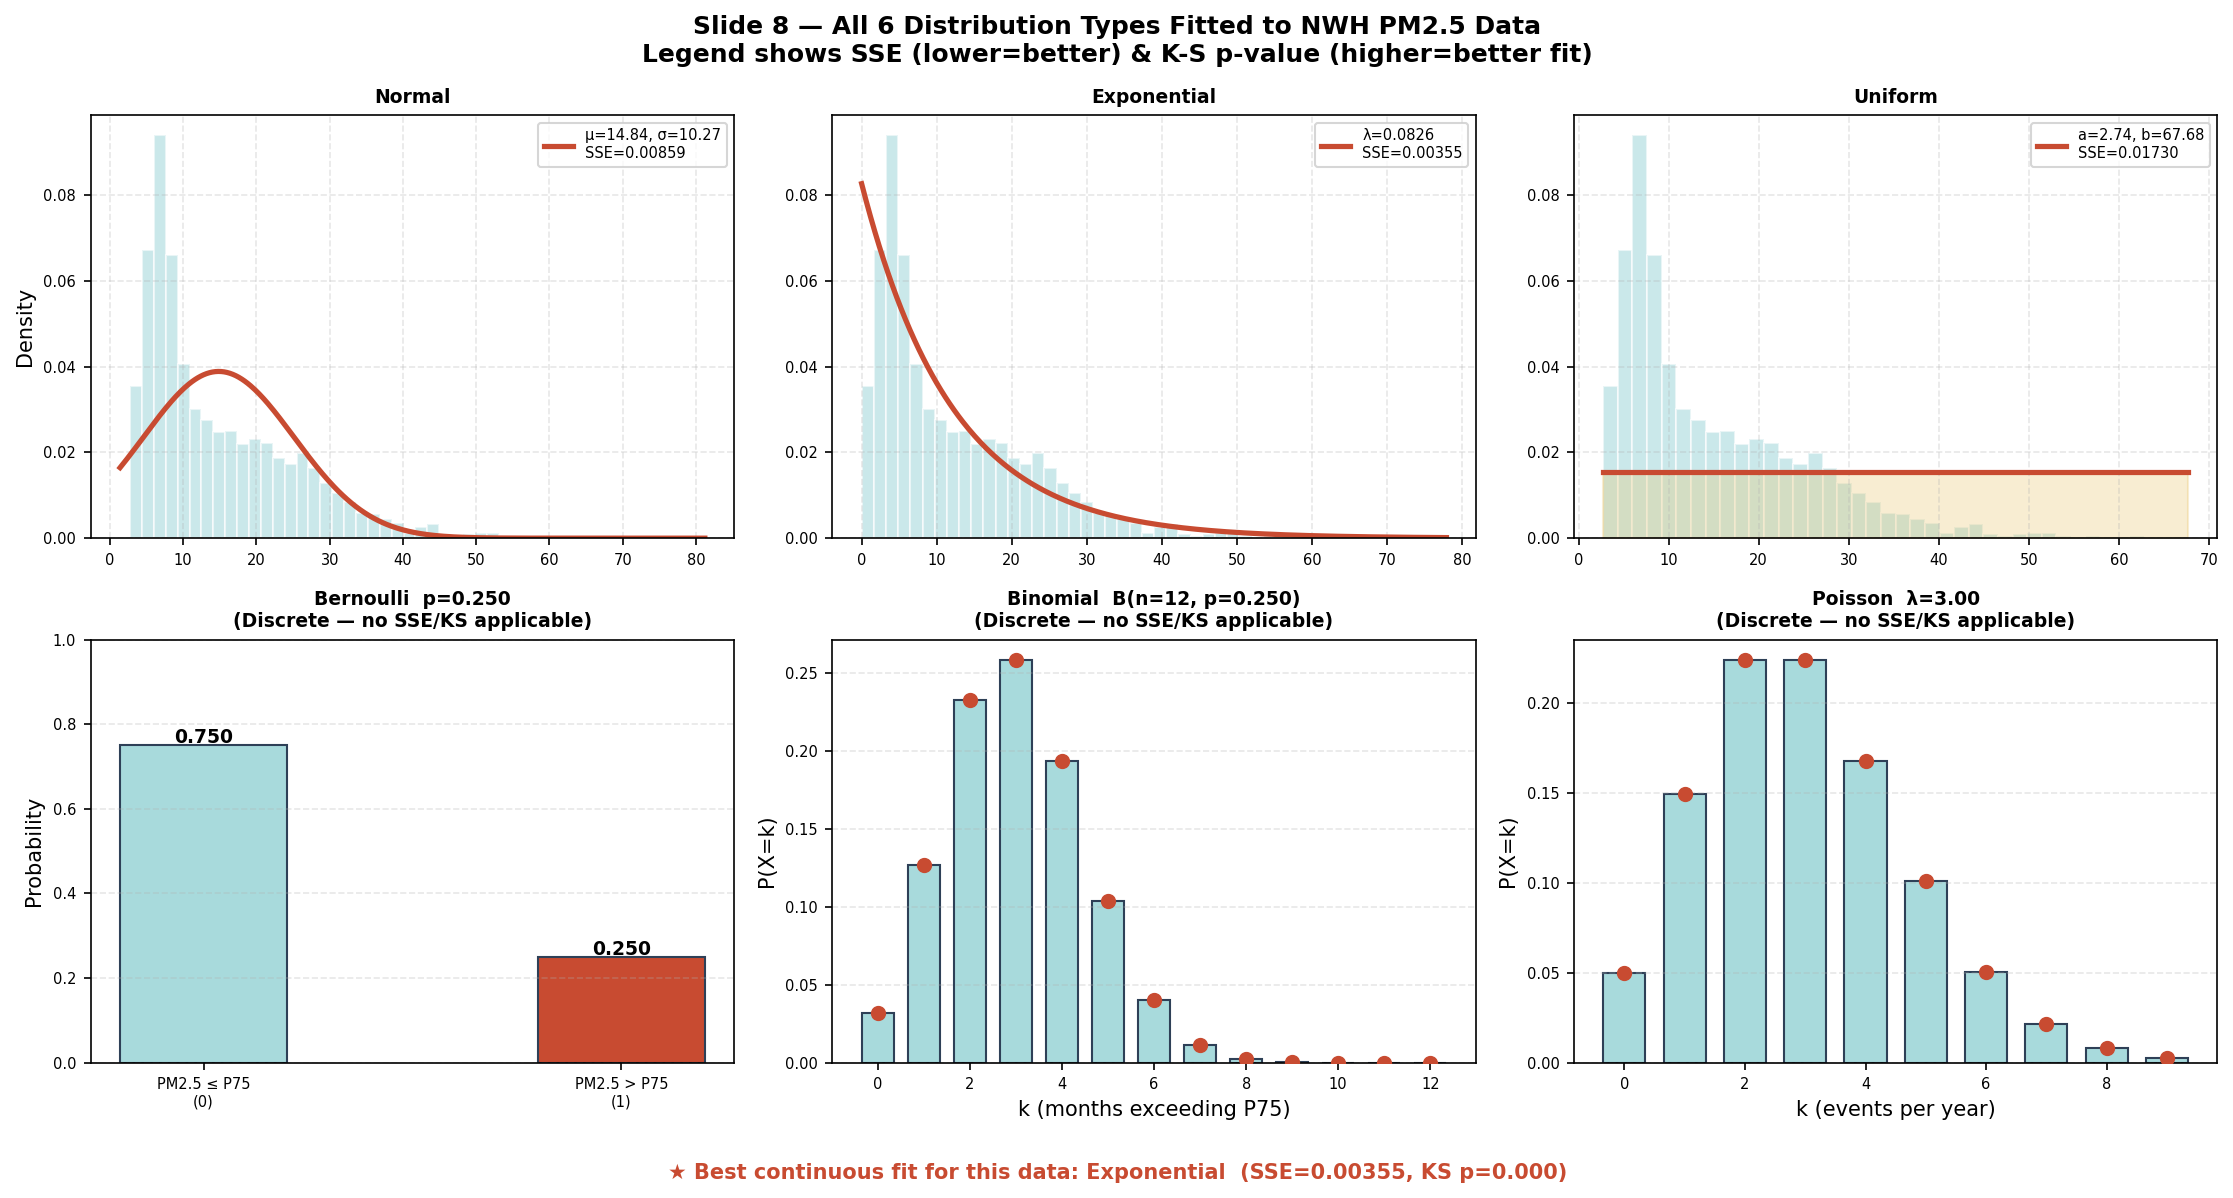

  ✅ Slide 8 saved


In [ ]:
def _fit_stats(data, dist, params, shift=False):
    """Return (SSE, ks_pval) for a fitted distribution vs histogram."""
    hist_y, bin_edges = np.histogram(data, bins=40, density=True)
    bin_c = (bin_edges[:-1] + bin_edges[1:]) / 2
    try:
        if shift:
            pdf_v = dist.pdf(bin_c - data.min(), *params)
            ks_stat, ks_p = kstest(data - data.min(), dist.cdf, args=params)
        else:
            pdf_v = dist.pdf(bin_c, *params)
            ks_stat, ks_p = kstest(data, dist.cdf, args=params)
        sse = float(np.sum((hist_y - pdf_v)**2))
        return round(sse, 5), round(float(ks_p))
    except Exception:
        return np.nan, np.nan

print("Plotting Slide 8: 6 Distribution Types …")
fig, axes = plt.subplots(2, 3, figsize=(15,8), dpi=150)
fig.suptitle("Slide 8 — All 6 Distribution Types Fitted to NWH PM2.5 Data\n"
             "Legend shows SSE (lower=better) & K-S p-value (higher=better fit)",
             fontsize=12, fontweight="bold")

xs = np.linspace(data_flat.min()*0.5, data_flat.max()*1.2, 400)
d  = data_flat
d_pos = d - d.min() + 1e-30

# ── Compute errors for continuous dists ───────────────────────────────────────
p_norm  = norm.fit(d);        sse_n,  ksp_n  = _fit_stats(d, norm,    p_norm)
p_exp   = expon.fit(d-d.min(), floc=0); sse_e, ksp_e = _fit_stats(d, expon, p_exp, shift=True)
p_unif  = (d.min(), d.max()-d.min())  # loc, scale for uniform
sse_u = float(np.sum((np.histogram(d,bins=40,density=True)[0] -
            uniform.pdf((np.histogram(d,bins=40,density=True,return_edges=False) if False else
                        (np.histogram(d,bins=40)[1][:-1]+np.histogram(d,bins=40)[1][1:])/2),
                        *p_unif))**2))
_, ksp_u = kstest(d, uniform.cdf, args=p_unif)
sse_u = round(sse_u,5); ksp_u = round(float(ksp_u),4)

# recompute sse_u cleanly
hist_y_u, be_u = np.histogram(d, bins=40, density=True)
bc_u = (be_u[:-1]+be_u[1:])/2
sse_u = round(float(np.sum((hist_y_u - uniform.pdf(bc_u, *p_unif))**2)),5)
_, ksp_u = kstest(d, uniform.cdf, args=p_unif); ksp_u=round(float(ksp_u),4)

# ── Normal ─────────────────────────────────────────────────────────────────────
ax = axes[0,0]
mu, s = p_norm
ax.hist(d, bins=40, density=True, color=COLORS["soft"], edgecolor="white", alpha=0.6)
ax.plot(xs, norm.pdf(xs,mu,s), color=COLORS["accent"], linewidth=2.5,
        label=f"μ={mu:.2f}, σ={s:.2f}\nSSE={sse_n:.5f}")
ax.set_title(f"Normal", fontsize=9, fontweight="bold")
ax.set_ylabel("Density"); ax.grid(True,linestyle="--",alpha=0.3)
ax.legend(fontsize=7, loc="upper right")

# ── Exponential ────────────────────────────────────────────────────────────────
ax = axes[0,1]
d_shift = d - d.min()
xs2 = np.linspace(0, d_shift.max()*1.2, 400)
ax.hist(d_shift, bins=40, density=True, color=COLORS["soft"], edgecolor="white", alpha=0.6)
ax.plot(xs2, expon.pdf(xs2, *p_exp), color=COLORS["accent"], linewidth=2.5,
        label=f"λ={1/p_exp[1]:.4f}\nSSE={sse_e:.5f}")
ax.set_title(f"Exponential", fontsize=9, fontweight="bold")
ax.grid(True,linestyle="--",alpha=0.3); ax.legend(fontsize=7, loc="upper right")

# ── Uniform ────────────────────────────────────────────────────────────────────
ax = axes[0,2]
a, b_u = d.min(), d.max()
ax.hist(d, bins=40, density=True, color=COLORS["soft"], edgecolor="white", alpha=0.6)
ax.plot([a,b_u],[1/(b_u-a),1/(b_u-a)], color=COLORS["accent"], linewidth=2.5,
        label=f"a={a:.2f}, b={b_u:.2f}\nSSE={sse_u:.5f}")
ax.fill_between([a,b_u],[0,0],[1/(b_u-a),1/(b_u-a)], alpha=0.3, color=COLORS["gold"])
ax.set_title("Uniform", fontsize=9, fontweight="bold")
ax.grid(True,linestyle="--",alpha=0.3); ax.legend(fontsize=7, loc="upper right")

# ── Bernoulli ──────────────────────────────────────────────────────────────────
ax = axes[1,0]
p = p_exceed
ax.bar([0,1],[1-p,p], color=[COLORS["soft"],COLORS["accent"]], edgecolor=COLORS["primary"], width=0.4)
ax.set_xticks([0,1]); ax.set_xticklabels(["PM2.5 ≤ P75\n(0)","PM2.5 > P75\n(1)"])
ax.set_ylabel("Probability")
for xi, yi in [(0,1-p),(1,p)]:
    ax.text(xi, yi+0.005, f"{yi:.3f}", ha="center", fontsize=9, fontweight="bold")
ax.set_ylim(0,1); ax.grid(True,axis="y",linestyle="--",alpha=0.3)
ax.set_title(f"Bernoulli  p={p:.3f}\n(Discrete — no SSE/KS applicable)", fontsize=9, fontweight="bold")

# ── Binomial ───────────────────────────────────────────────────────────────────
ax = axes[1,1]
n_binom = 12
k_vals = np.arange(0, n_binom+1)
binom_pmf = binom.pmf(k_vals, n_binom, p_exceed)
ax.bar(k_vals, binom_pmf, color=COLORS["soft"], edgecolor=COLORS["primary"], width=0.7)
ax.scatter(k_vals, binom_pmf, color=COLORS["accent"], s=40, zorder=5)
ax.set_xlabel("k (months exceeding P75)"); ax.set_ylabel("P(X=k)")
ax.set_title(f"Binomial  B(n=12, p={p_exceed:.3f})\n(Discrete — no SSE/KS applicable)", fontsize=9, fontweight="bold")
ax.grid(True,axis="y",linestyle="--",alpha=0.3)

# ── Poisson ────────────────────────────────────────────────────────────────────
ax = axes[1,2]
lam = p_exceed * 12
k_pois = np.arange(0, int(lam*3)+1)
pois_pmf = poisson.pmf(k_pois, lam)
ax.bar(k_pois, pois_pmf, color=COLORS["soft"], edgecolor=COLORS["primary"], width=0.7)
ax.scatter(k_pois, pois_pmf, color=COLORS["accent"], s=40, zorder=5)
ax.set_xlabel("k (events per year)"); ax.set_ylabel("P(X=k)")
ax.set_title(f"Poisson  λ={lam:.2f}\n(Discrete — no SSE/KS applicable)", fontsize=9, fontweight="bold")
ax.grid(True,axis="y",linestyle="--",alpha=0.3)

# ── Rank continuous dists by SSE ──────────────────────────────────────────────
cont_errors = {"Normal":(sse_n,ksp_n), "Exponential":(sse_e,ksp_e), "Uniform":(sse_u,ksp_u)}
best_cont = min(cont_errors, key=lambda k: cont_errors[k][0] if not np.isnan(cont_errors[k][0]) else 9999)
fig.text(0.5, 0.01,
         f"★ Best continuous fit for this data: {best_cont}  "
         f"(SSE={cont_errors[best_cont][0]:.5f}, KS p={cont_errors[best_cont][1]:.3f})",
         ha="center", fontsize=10, fontweight="bold", color=COLORS["accent"])

for ax in axes.flat:
    ax.tick_params(labelsize=7)
fig.tight_layout(rect=[0,0.04,1,1])
fig.savefig(os.path.join(OUT_DIR,"Slide08_Six_Distribution_Types.png"), dpi=150, bbox_inches="tight")
plt.show()
print("  ✅ Slide 8 saved")


## Slides 9–11 — Normal, Exponential & Uniform Distributions

Plotting Slides 9–11: Individual continuous distributions …


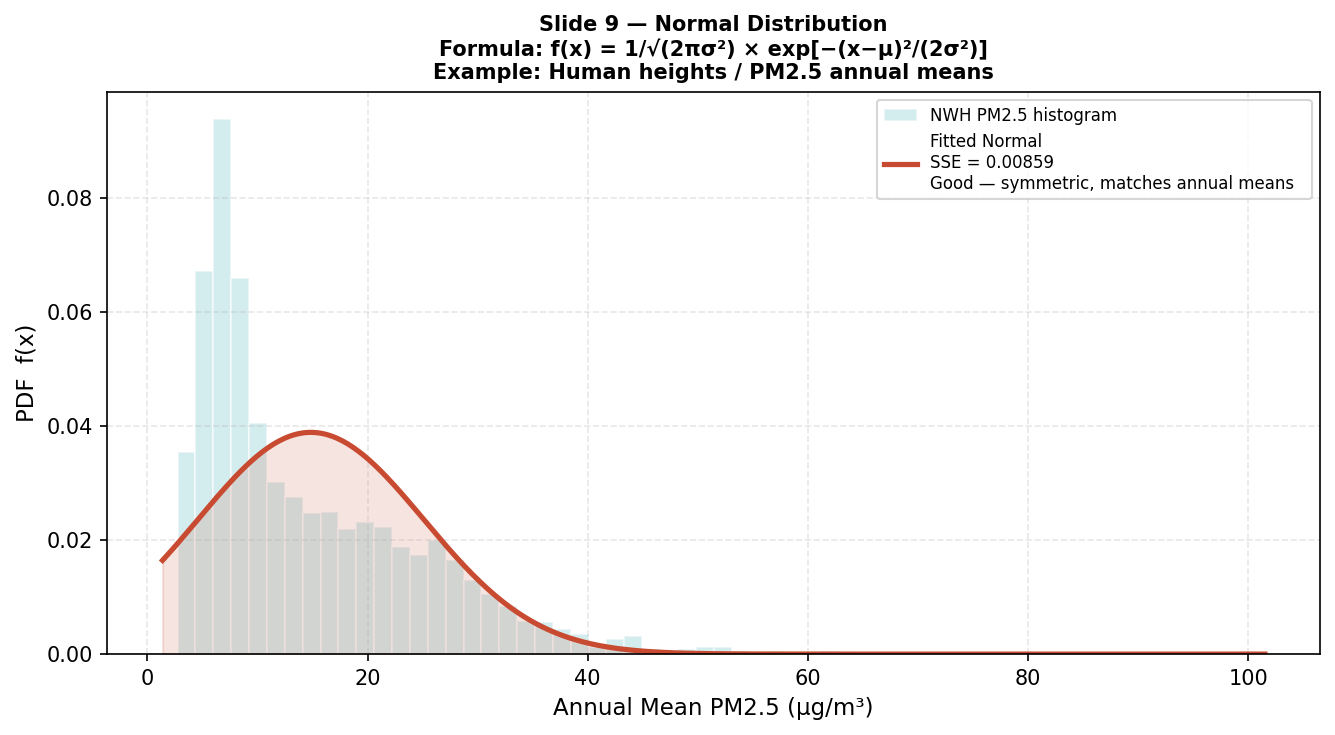

  ✅ Slide 9 saved  (SSE=0.00859)


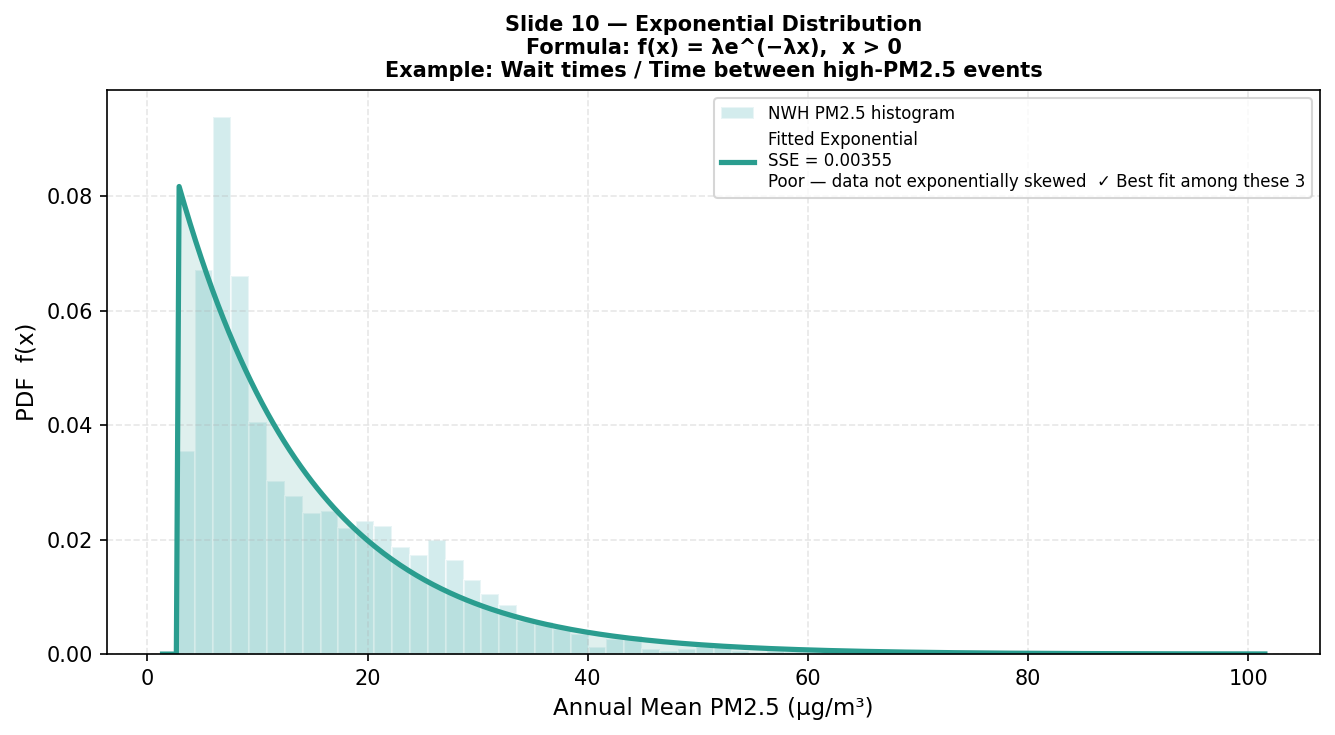

  ✅ Slide 10 saved  (SSE=0.00355)


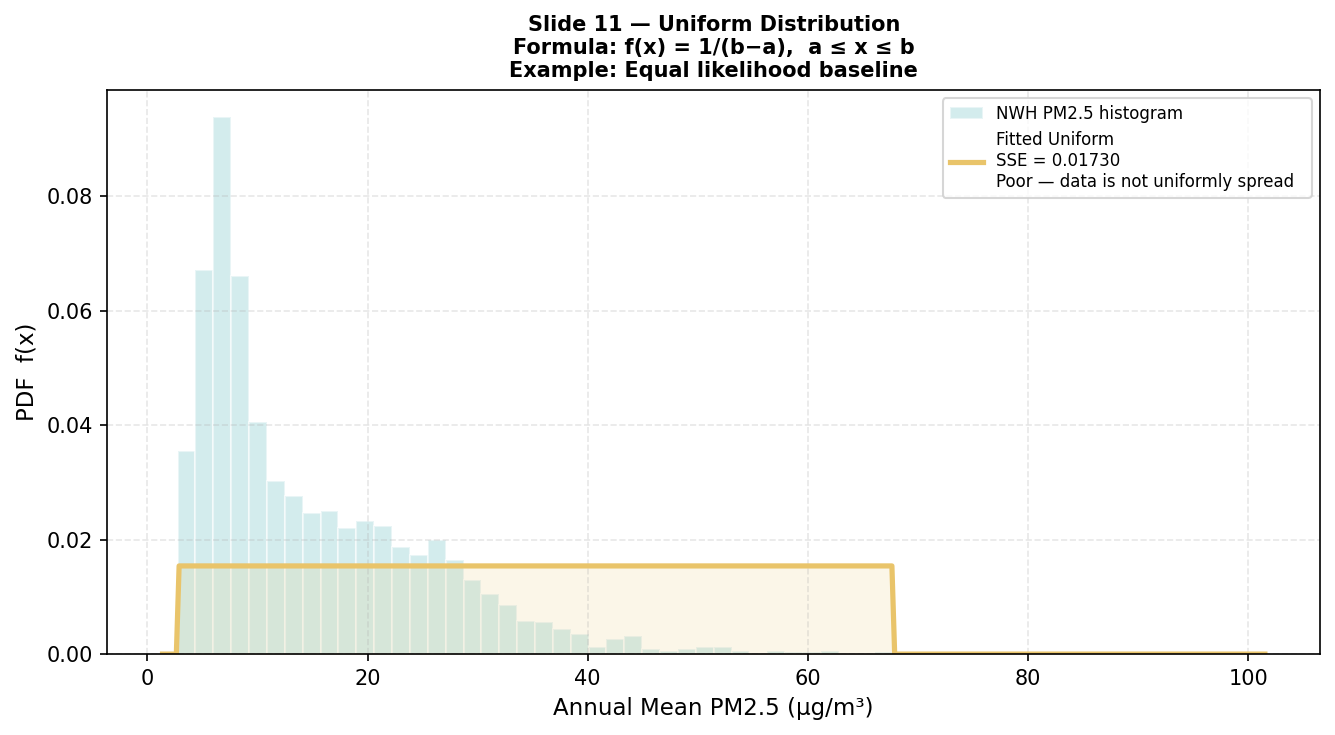

  ✅ Slide 11 saved  (SSE=0.01730)


In [ ]:
def _fit_stats(data, dist, params, shift=False):
    """Return (SSE, ks_pval) for a fitted distribution vs histogram."""
    hist_y, bin_edges = np.histogram(data, bins=40, density=True)
    bin_c = (bin_edges[:-1] + bin_edges[1:]) / 2
    try:
        if shift:
            pdf_v = dist.pdf(bin_c - data.min(), *params)
            ks_stat, ks_p = kstest(data - data.min(), dist.cdf, args=params)
        else:
            pdf_v = dist.pdf(bin_c, *params)
            ks_stat, ks_p = kstest(data, dist.cdf, args=params)
        sse = float(np.sum((hist_y - pdf_v)**2))
        return round(sse, 5), round(float(ks_p), 4)
    except Exception:
        return np.nan, np.nan

print("Plotting Slides 9–11: Individual continuous distributions …")

d_pos = data_flat - data_flat.min() + 1e-30

dist_configs = [
    (9,  "Normal Distribution",
     "f(x) = 1/√(2πσ²) × exp[−(x−μ)²/(2σ²)]",
     "Human heights / PM2.5 annual means",
     norm,   norm.fit(data_flat),         False, COLORS["accent"]),
    (10, "Exponential Distribution",
     "f(x) = λe^(−λx),  x > 0",
     "Wait times / Time between high-PM2.5 events",
     expon,  expon.fit(data_flat-data_flat.min(), floc=0), True, COLORS["green"]),
    (11, "Uniform Distribution",
     "f(x) = 1/(b−a),  a ≤ x ≤ b",
     "Equal likelihood baseline",
     uniform, (data_flat.min(), data_flat.max()-data_flat.min()), False, COLORS["gold"]),
]

# Pre-compute errors for all three so we can rank
errors = {}
for slide, title, formula, example, dist_obj, params, shift, col in dist_configs:
    sse, ksp = _fit_stats(data_flat, dist_obj, params, shift=shift)
    errors[title.split()[0]] = (sse, ksp)
best_name = min(errors, key=lambda k: errors[k][0] if not np.isnan(errors[k][0]) else 9999)

for slide, title, formula, example, dist_obj, params, shift, col in dist_configs:
    fig, ax = plt.subplots(figsize=(9,5), dpi=150)
    xs = np.linspace(data_flat.min()*0.5, data_flat.max()*1.5, 400)
    dname = title.split()[0]
    sse, ksp = errors[dname]

    if shift:
        ys = dist_obj.pdf(xs - data_flat.min(), *params)
    else:
        ys = dist_obj.pdf(xs, *params)
    ys = np.where(np.isfinite(ys), ys, 0)

    fit_quality = "✓ Best fit among these 3" if dname == best_name else ""
    suitability = "Good — symmetric, matches annual means" if dname == "Normal" else                   "Poor — data not exponentially skewed" if dname == "Exponential" else                   "Poor — data is not uniformly spread"

    ax.hist(data_flat, bins=40, density=True, color=COLORS["soft"],
            edgecolor="white", alpha=0.5, label="NWH PM2.5 histogram")
    ax.plot(xs, ys, color=col, linewidth=2.5,
            label=f"Fitted {dname}\nSSE = {sse:.5f}\n{suitability}  {fit_quality}")
    ax.fill_between(xs, ys, alpha=0.15, color=col)
    ax.set_xlabel("Annual Mean PM2.5 (µg/m³)", fontsize=11)
    ax.set_ylabel("PDF  f(x)", fontsize=11)
    ax.set_title(f"Slide {slide} — {title}\nFormula: {formula}\nExample: {example}",
                 fontsize=10, fontweight="bold")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True, linestyle="--", alpha=0.3)
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, f"Slide{slide:02d}_{dname}_Distribution.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  ✅ Slide {slide} saved  (SSE={sse:.5f})")
    plt.close()


## Slides 12–14 — Bernoulli, Binomial & Poisson Distributions

Plotting Slides 12–14: Discrete distributions …


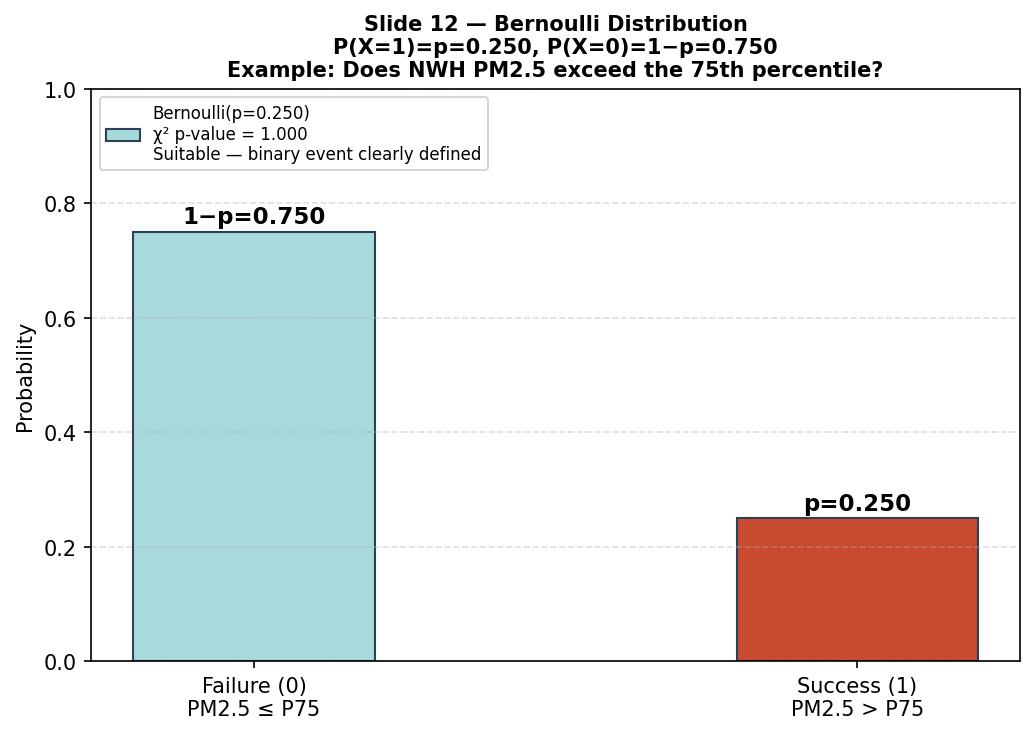

  ✅ Slide 12 saved  (χ² p=1.000)


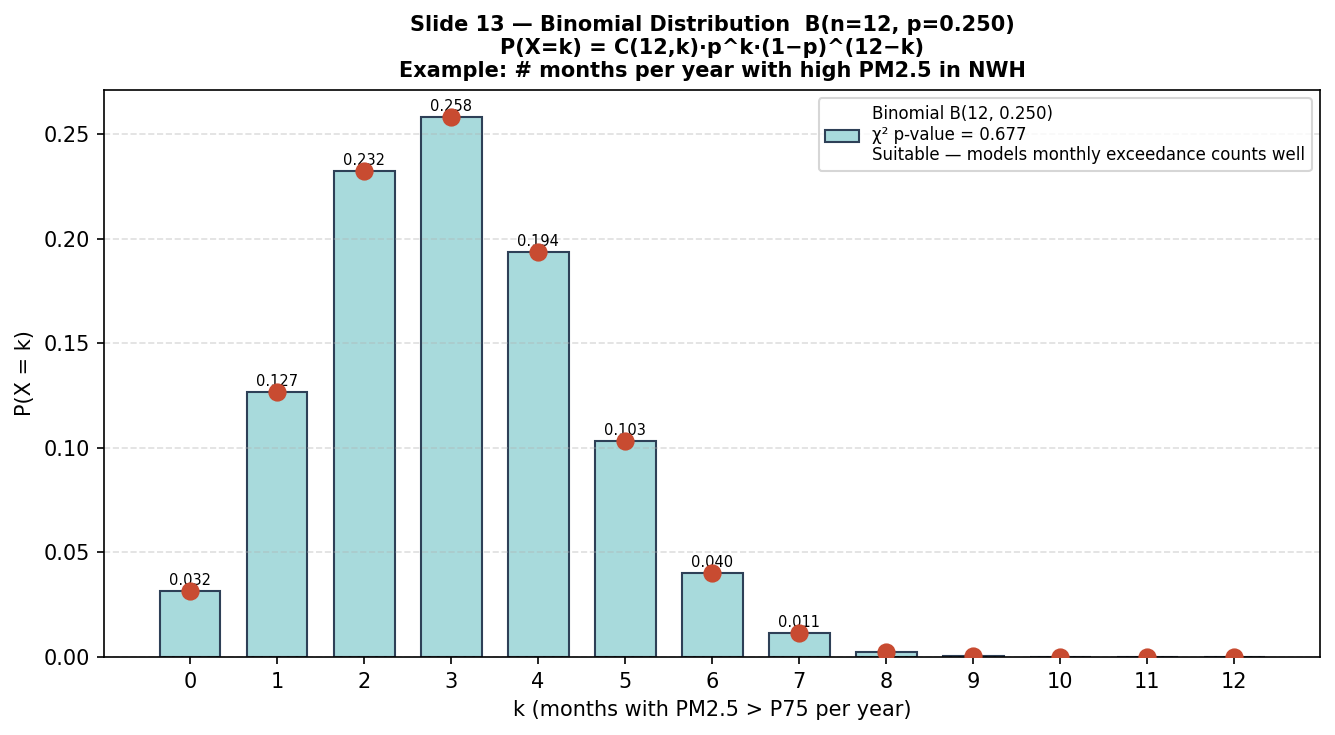

  ✅ Slide 13 saved  (χ² p=0.677)


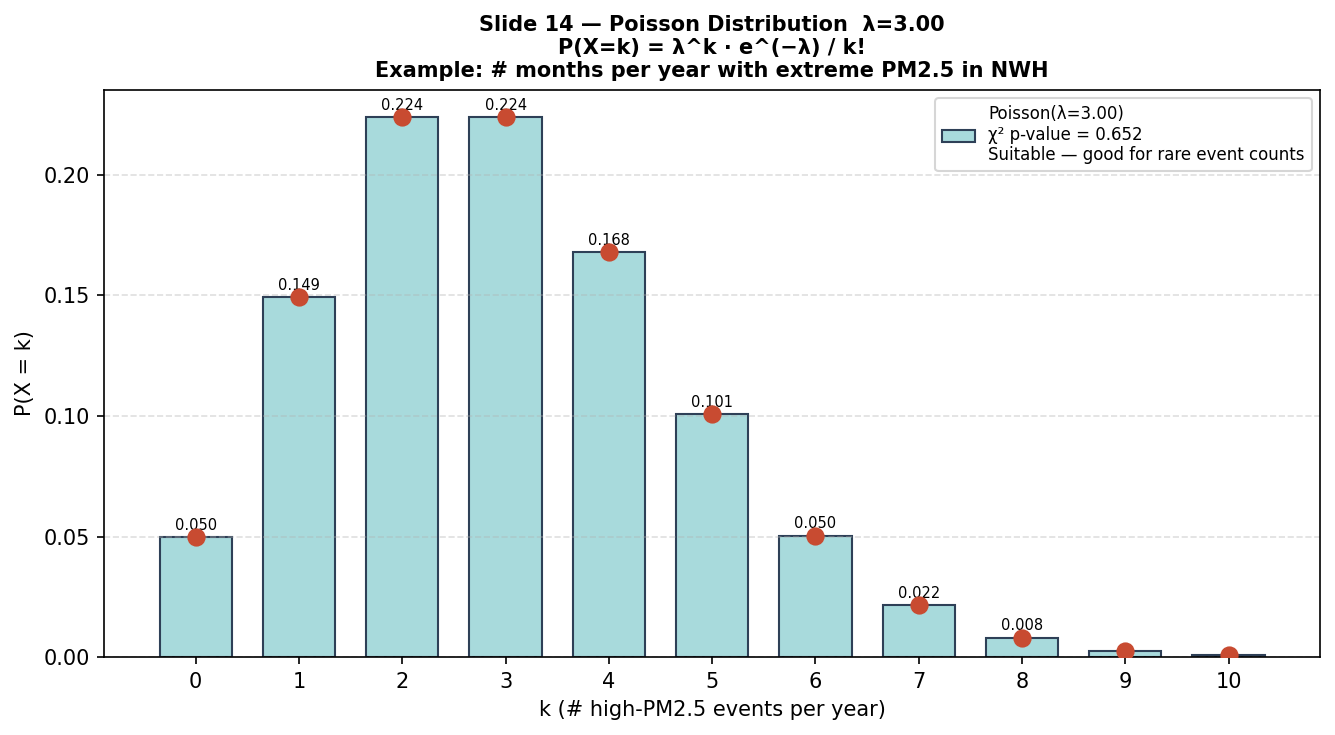

  ✅ Slide 14 saved  (χ² p=0.652)


In [ ]:
print("Plotting Slides 12–14: Discrete distributions …")

from scipy.stats import chisquare

# ── Bernoulli ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7,5), dpi=150)
n_total  = len(data_flat)
obs_fail = np.sum(data_flat <= threshold)
obs_succ = np.sum(data_flat >  threshold)
exp_fail = n_total * (1 - p_exceed)
exp_succ = n_total * p_exceed
chi2_b, pval_b = chisquare([obs_fail, obs_succ], [exp_fail, exp_succ])
suitability_b = "Suitable — binary event clearly defined" if pval_b > 0.05 else "Moderate fit"

ax.bar([0,1],[1-p_exceed,p_exceed], color=[COLORS["soft"],COLORS["accent"]],
       edgecolor=COLORS["primary"], width=0.4,
       label=f"Bernoulli(p={p_exceed:.3f})\nχ² p-value = {pval_b:.3f}\n{suitability_b}")
ax.set_xticks([0,1])
ax.set_xticklabels(["Failure (0)\nPM2.5 ≤ P75","Success (1)\nPM2.5 > P75"])
ax.set_ylabel("Probability")
ax.set_ylim(0,1)
ax.set_title(f"Slide 12 — Bernoulli Distribution\n"
             f"P(X=1)=p={p_exceed:.3f}, P(X=0)=1−p={1-p_exceed:.3f}\n"
             f"Example: Does NWH PM2.5 exceed the {THRESHOLD_PERCENTILE}th percentile?",
             fontsize=10, fontweight="bold")
for xi, yi, lbl in [(0, 1-p_exceed, f"1−p={1-p_exceed:.3f}"),
                    (1, p_exceed,   f"p={p_exceed:.3f}")]:
    ax.text(xi, yi+0.015, lbl, ha="center", fontsize=11, fontweight="bold")
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR,"Slide12_Bernoulli_Distribution.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"  ✅ Slide 12 saved  (χ² p={pval_b:.3f})")
plt.close()

# ── Binomial ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9,5), dpi=150)
k_vals = np.arange(0, 13)
bpmf   = binom.pmf(k_vals, 12, p_exceed)

months_per_yr = np.array([np.sum(monthly_arr[j, :] > threshold)
                           for j in range(len(year_list))])
obs_counts = np.array([np.sum(months_per_yr == k) for k in k_vals], dtype=float)
exp_counts = bpmf * len(year_list)

# Merge low-expected bins, then rescale expected to match observed sum exactly
mask = exp_counts >= 1
obs_m = obs_counts[mask]
exp_m = exp_counts[mask]
exp_m = exp_m * (obs_m.sum() / exp_m.sum())   # ✅ normalise sums to match

chi2_bin, pval_bin = chisquare(obs_m, exp_m)
suitability_bin = ("Suitable — models monthly exceedance counts well"
                   if pval_bin > 0.05 else "Moderate fit")

bars = ax.bar(k_vals, bpmf, color=COLORS["soft"], edgecolor=COLORS["primary"], width=0.7,
              label=f"Binomial B(12, {p_exceed:.3f})\nχ² p-value = {pval_bin:.3f}\n{suitability_bin}")
ax.scatter(k_vals, bpmf, color=COLORS["accent"], s=60, zorder=5)
for bar, yv in zip(bars, bpmf):
    if yv > 0.005:
        ax.text(bar.get_x()+bar.get_width()/2, yv+0.003,
                f"{yv:.3f}", ha="center", fontsize=7)
ax.set_xlabel("k (months with PM2.5 > P75 per year)", fontsize=10)
ax.set_ylabel("P(X = k)", fontsize=10)
ax.set_title(f"Slide 13 — Binomial Distribution  B(n=12, p={p_exceed:.3f})\n"
             f"P(X=k) = C(12,k)·p^k·(1−p)^(12−k)\n"
             f"Example: # months per year with high PM2.5 in NWH",
             fontsize=10, fontweight="bold")
ax.set_xticks(k_vals)
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR,"Slide13_Binomial_Distribution.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"  ✅ Slide 13 saved  (χ² p={pval_bin:.3f})")
plt.close()

# ── Poisson ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9,5), dpi=150)
lam_p  = p_exceed * 12
k_pois = np.arange(0, int(lam_p*3)+2)
ppmf   = poisson.pmf(k_pois, lam_p)

obs_pois = np.array([np.sum(months_per_yr == k) for k in k_pois], dtype=float)
exp_pois = ppmf * len(year_list)

# Merge low-expected bins, then rescale expected to match observed sum exactly
mask_p  = exp_pois >= 1
obs_pm  = obs_pois[mask_p]
exp_pm  = exp_pois[mask_p]
exp_pm  = exp_pm * (obs_pm.sum() / exp_pm.sum())   # ✅ normalise sums to match

chi2_p, pval_pois = chisquare(obs_pm, exp_pm)
suitability_pois = ("Suitable — good for rare event counts"
                    if pval_pois > 0.05 else "Moderate fit")

bars = ax.bar(k_pois, ppmf, color=COLORS["soft"], edgecolor=COLORS["primary"], width=0.7,
              label=f"Poisson(λ={lam_p:.2f})\nχ² p-value = {pval_pois:.3f}\n{suitability_pois}")
ax.scatter(k_pois, ppmf, color=COLORS["accent"], s=60, zorder=5)
for bar, yv in zip(bars, ppmf):
    if yv > 0.005:
        ax.text(bar.get_x()+bar.get_width()/2, yv+0.003,
                f"{yv:.3f}", ha="center", fontsize=7)
ax.set_xlabel("k (# high-PM2.5 events per year)", fontsize=10)
ax.set_ylabel("P(X = k)", fontsize=10)
ax.set_title(f"Slide 14 — Poisson Distribution  λ={lam_p:.2f}\n"
             f"P(X=k) = λ^k · e^(−λ) / k!\n"
             f"Example: # months per year with extreme PM2.5 in NWH",
             fontsize=10, fontweight="bold")
ax.set_xticks(k_pois)
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR,"Slide14_Poisson_Distribution.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"  ✅ Slide 14 saved  (χ² p={pval_pois:.3f})")
plt.close()

## Slide 15 — Data Understanding: Normal / Skewed / Multimodal

Plotting Slide 15: Data Understanding …


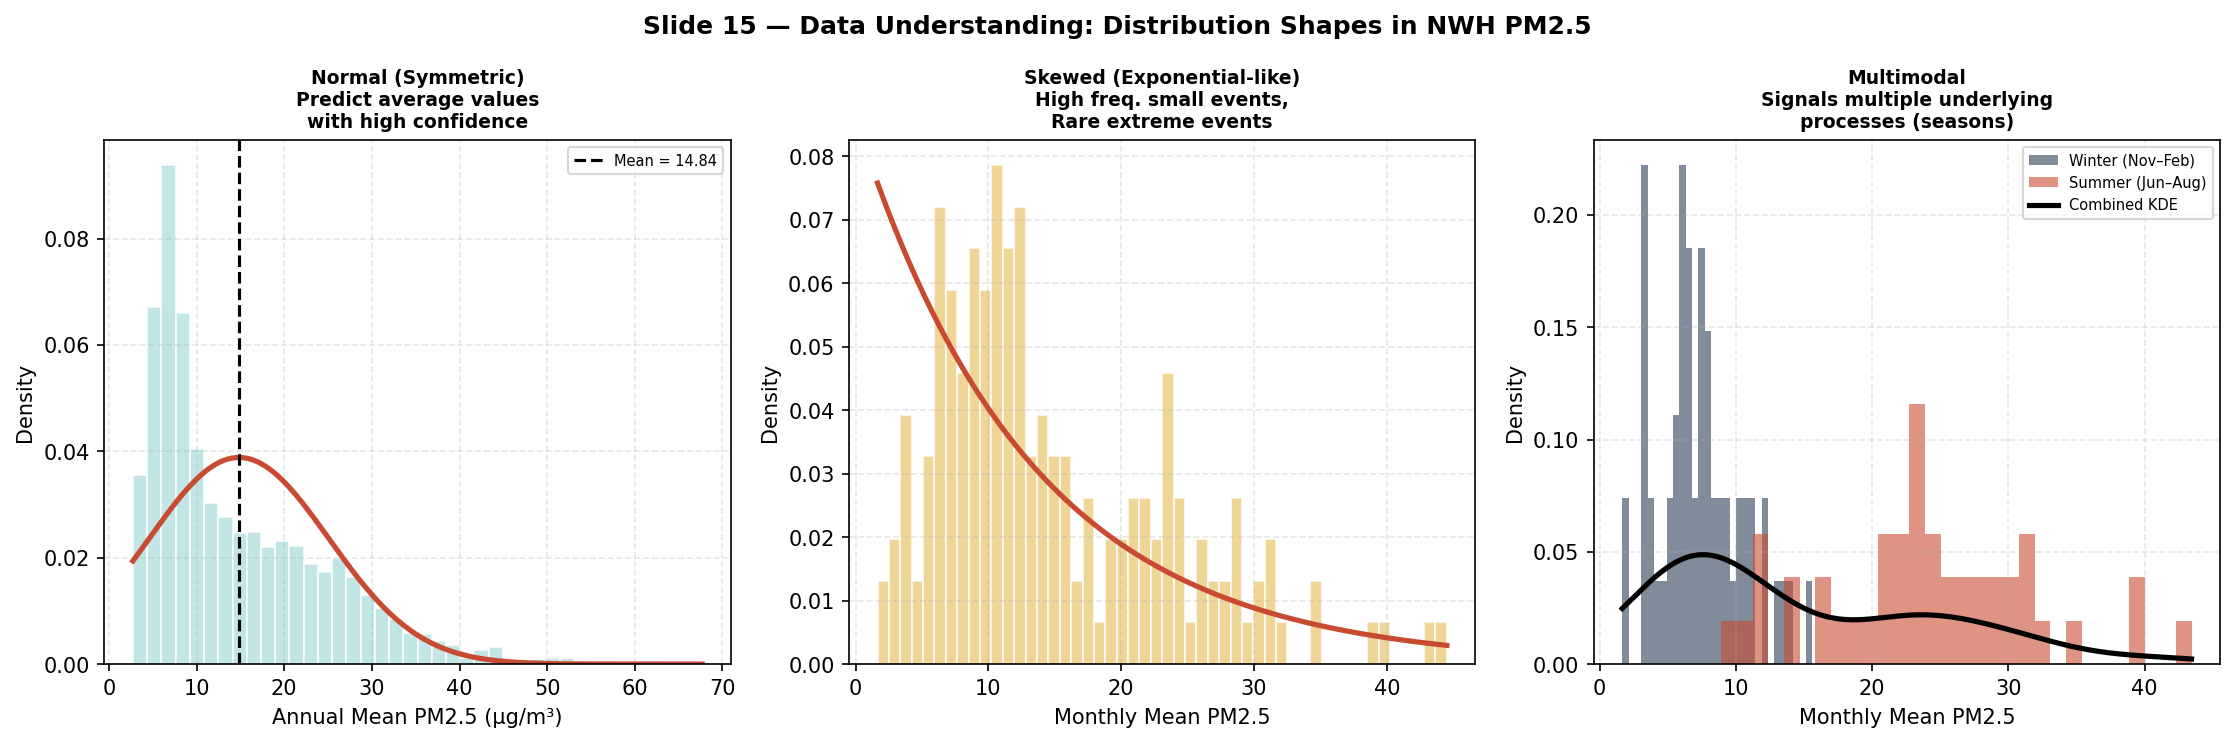

  ✅ Slide 15 saved


In [ ]:
print("Plotting Slide 15: Data Understanding …")
fig, axes = plt.subplots(1, 3, figsize=(15,5), dpi=150)
fig.suptitle("Slide 15 — Data Understanding: Distribution Shapes in NWH PM2.5",
             fontsize=12, fontweight="bold")

# Normal
ax = axes[0]
ax.hist(data_flat, bins=40, density=True, color=COLORS["soft"], edgecolor="white", alpha=0.7)
mu, s = norm.fit(data_flat)
xs = np.linspace(data_flat.min(), data_flat.max(), 300)
ax.plot(xs, norm.pdf(xs, mu, s), color=COLORS["accent"], linewidth=2.5)
ax.axvline(mu, color="black", linestyle="--", linewidth=1.5, label=f"Mean = {mu:.2f}")
ax.set_title("Normal (Symmetric)\nPredict average values\nwith high confidence", fontsize=9, fontweight="bold")
ax.set_xlabel("Annual Mean PM2.5 (µg/m³)"); ax.set_ylabel("Density"); ax.legend(fontsize=7)
ax.grid(True,linestyle="--",alpha=0.3)

# Skewed
ax = axes[1]
ax.hist(monthly_flat, bins=50, density=True, color=COLORS["gold"], edgecolor="white", alpha=0.7)
loc_e, scale_e = expon.fit(monthly_flat-monthly_flat.min(), floc=0)
xs2 = np.linspace(0, monthly_flat.max()-monthly_flat.min(), 300)
ax.plot(xs2+monthly_flat.min(), expon.pdf(xs2, loc_e, scale_e), color=COLORS["accent"], linewidth=2.5)
ax.set_title("Skewed (Exponential-like)\nHigh freq. small events,\nRare extreme events", fontsize=9, fontweight="bold")
ax.set_xlabel("Monthly Mean PM2.5"); ax.set_ylabel("Density")
ax.grid(True,linestyle="--",alpha=0.3)

# Multimodal
ax = axes[2]
ax.hist(winter_vals, bins=30, density=True, alpha=0.6, color=COLORS["primary"], label="Winter (Nov–Feb)")
ax.hist(summer_vals, bins=30, density=True, alpha=0.6, color=COLORS["accent"], label="Summer (Jun–Aug)")
kde_all = stats.gaussian_kde(np.concatenate([winter_vals, summer_vals]))
xs_all  = np.linspace(min(winter_vals.min(), summer_vals.min()),
                      max(winter_vals.max(), summer_vals.max()), 300)
ax.plot(xs_all, kde_all(xs_all), color="black", linewidth=2.5, label="Combined KDE")
ax.set_title("Multimodal\nSignals multiple underlying\nprocesses (seasons)", fontsize=9, fontweight="bold")
ax.set_xlabel("Monthly Mean PM2.5"); ax.set_ylabel("Density"); ax.legend(fontsize=7)
ax.grid(True,linestyle="--",alpha=0.3)

fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR,"Slide15_Data_Understanding_Shapes.png"), dpi=150, bbox_inches="tight")
plt.show()
print("  ✅ Slide 15 saved")


## Slide 17 — Step 1: Visual Inspection (Histogram + KDE + Boxplot)

Plotting Slide 17: Step 1 Visual Inspection …


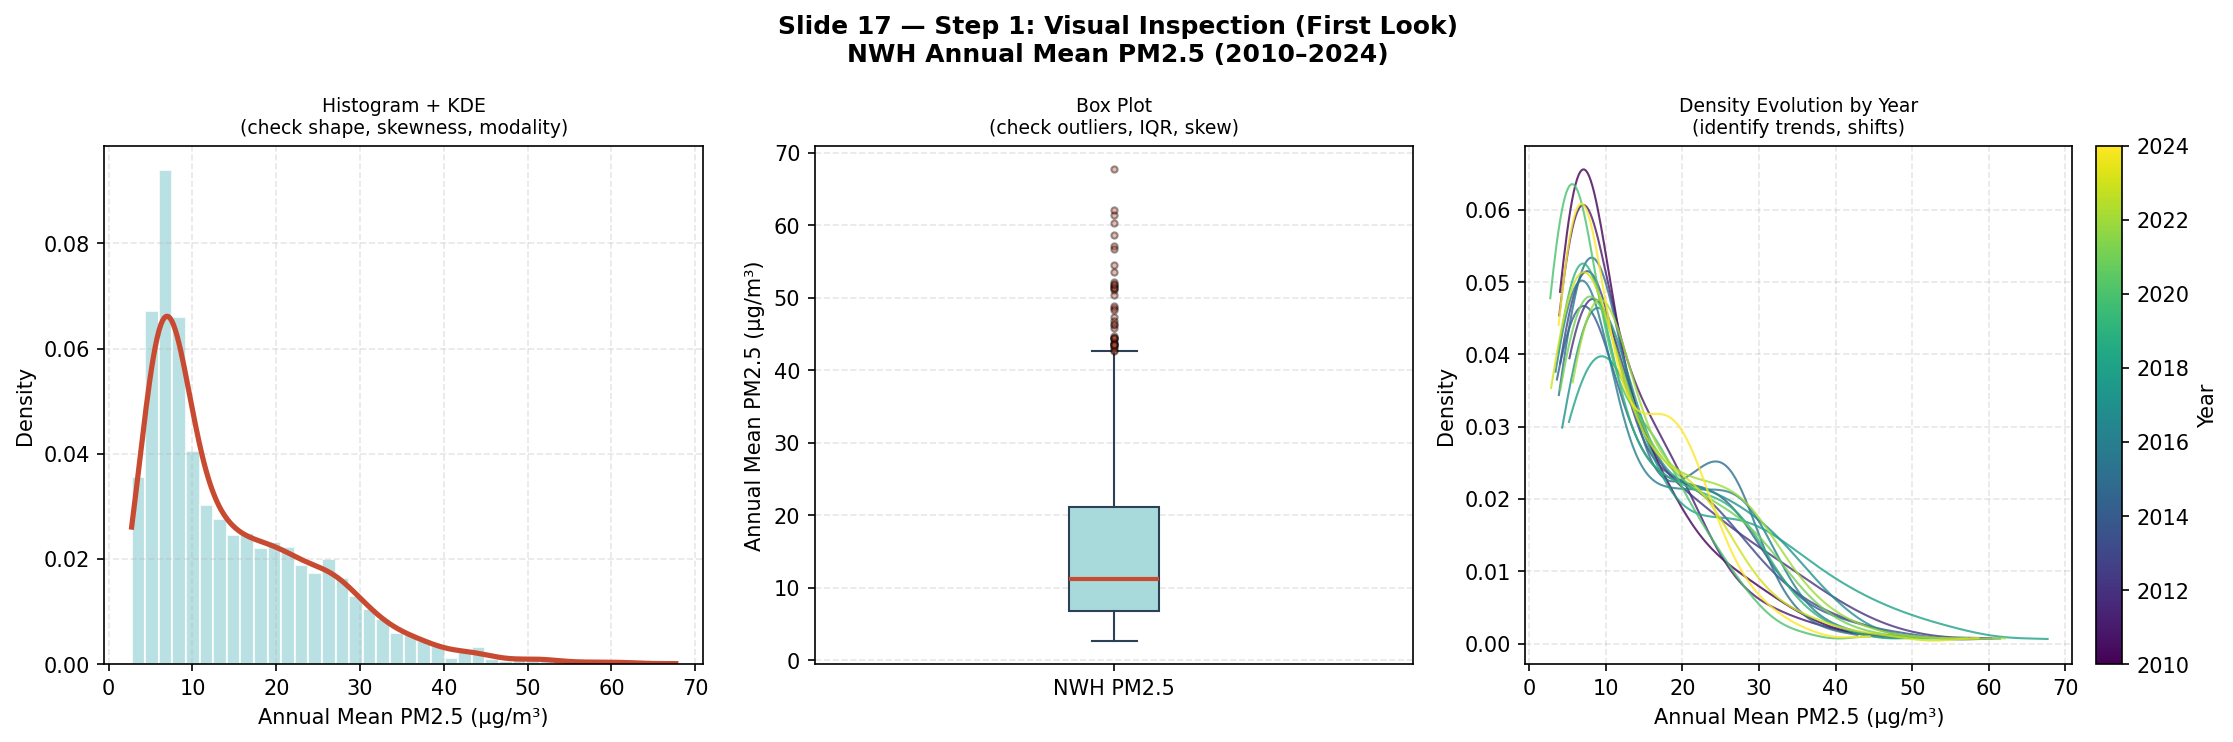

  ✅ Slide 17 saved


In [ ]:
print("Plotting Slide 17: Step 1 Visual Inspection …")
fig = plt.figure(figsize=(15,5), dpi=150)
fig.suptitle("Slide 17 — Step 1: Visual Inspection (First Look)\nNWH Annual Mean PM2.5 (2010–2024)",
             fontsize=12, fontweight="bold")
gs = gridspec.GridSpec(1,3, figure=fig)

# Histogram
ax1 = fig.add_subplot(gs[0])
ax1.hist(data_flat, bins=40, density=True, color=COLORS["soft"], edgecolor="white", alpha=0.8)
kde = stats.gaussian_kde(data_flat)
xs  = np.linspace(data_flat.min(), data_flat.max(), 300)
ax1.plot(xs, kde(xs), color=COLORS["accent"], linewidth=2.5)
ax1.set_xlabel("Annual Mean PM2.5 (µg/m³)"); ax1.set_ylabel("Density")
ax1.set_title("Histogram + KDE\n(check shape, skewness, modality)", fontsize=9)
ax1.grid(True,linestyle="--",alpha=0.3)

# Box plot
ax2 = fig.add_subplot(gs[1])
bp = ax2.boxplot(data_flat, vert=True, patch_artist=True,
                 boxprops=dict(facecolor=COLORS["soft"], color=COLORS["primary"]),
                 medianprops=dict(color=COLORS["accent"], linewidth=2),
                 whiskerprops=dict(color=COLORS["primary"]),
                 capprops=dict(color=COLORS["primary"]),
                 flierprops=dict(marker="o",markerfacecolor=COLORS["accent"],markersize=3,alpha=0.4))
ax2.set_ylabel("Annual Mean PM2.5 (µg/m³)")
ax2.set_title("Box Plot\n(check outliers, IQR, skew)", fontsize=9)
ax2.set_xticks([1]); ax2.set_xticklabels(["NWH PM2.5"])
ax2.grid(True,axis="y",linestyle="--",alpha=0.3)

# Yearly KDE evolution
ax3 = fig.add_subplot(gs[2])
cmap_yr = plt.cm.viridis(np.linspace(0,1,n_years))
for j, (yr, col) in enumerate(zip(year_list, cmap_yr)):
    yi = Y_clip[:,j]; yi = yi[~np.isnan(yi)]
    if len(yi)<4: continue
    kde_j = stats.gaussian_kde(yi)
    xs_j  = np.linspace(yi.min(), yi.max(), 200)
    ax3.plot(xs_j, kde_j(xs_j), color=col, linewidth=1, alpha=0.8)
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=mcolors.Normalize(year_list[0], year_list[-1]))
plt.colorbar(sm, ax=ax3, label="Year", fraction=0.046, pad=0.04)
ax3.set_xlabel("Annual Mean PM2.5 (µg/m³)"); ax3.set_ylabel("Density")
ax3.set_title("Density Evolution by Year\n(identify trends, shifts)", fontsize=9)
ax3.grid(True,linestyle="--",alpha=0.3)

fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR,"Slide17_Step1_Visual_Inspection.png"), dpi=150, bbox_inches="tight")
plt.show()
print("  ✅ Slide 17 saved")


## Slide 18 — Step 2: Fitting Common Distributions

Plotting Slide 18: Step 2 Fitting …


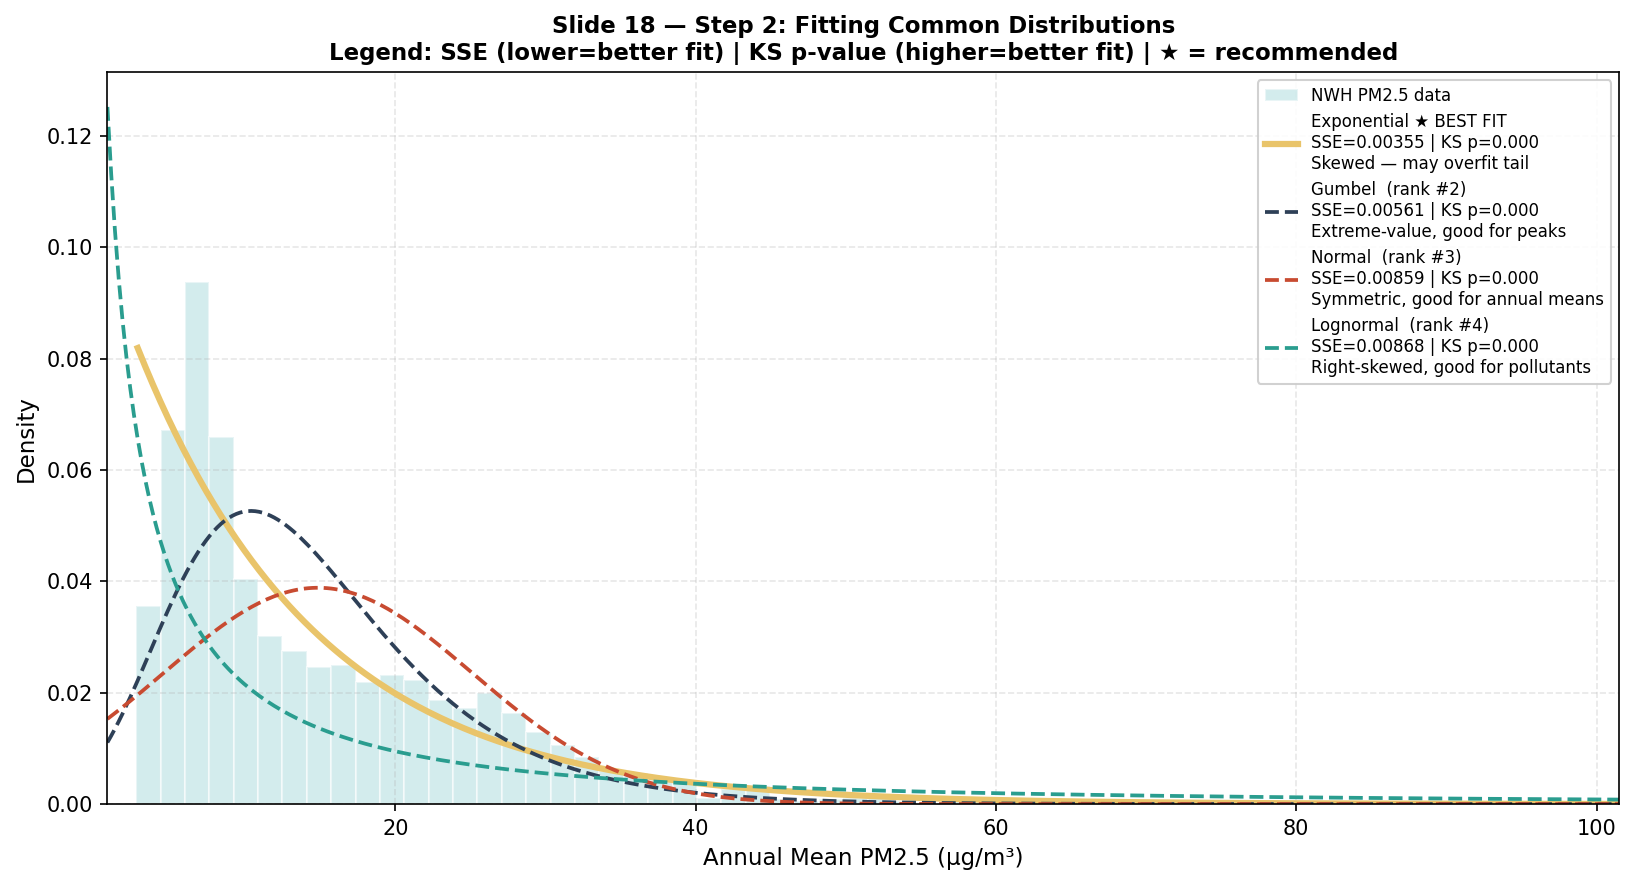

  ✅ Slide 18 saved

SSE Ranking (best → worst):
  1. Exponential: SSE=0.00355, KS p=0.000 ← BEST
  2. Gumbel: SSE=0.00561, KS p=0.000
  3. Normal: SSE=0.00859, KS p=0.000
  4. Lognormal: SSE=0.00868, KS p=0.000


In [ ]:
def _fit_stats(data, dist, params, shift=False):
    """Return (SSE, ks_pval) for a fitted distribution vs histogram."""
    hist_y, bin_edges = np.histogram(data, bins=40, density=True)
    bin_c = (bin_edges[:-1] + bin_edges[1:]) / 2
    try:
        if shift:
            pdf_v = dist.pdf(bin_c - data.min(), *params)
            ks_stat, ks_p = kstest(data - data.min(), dist.cdf, args=params)
        else:
            pdf_v = dist.pdf(bin_c, *params)
            ks_stat, ks_p = kstest(data, dist.cdf, args=params)
        sse = float(np.sum((hist_y - pdf_v)**2))
        return round(sse, 5), round(float(ks_p), 4)
    except Exception:
        return np.nan, np.nan

print("Plotting Slide 18: Step 2 Fitting …")
d_pos = data_flat - data_flat.min() + 1e-30

fits = [
    ("Normal",      norm,     norm.fit(data_flat),                        False, COLORS["accent"]),
    ("Lognormal",   lognorm,  lognorm.fit(d_pos, floc=0),                 False, COLORS["green"]),
    ("Exponential", expon,    expon.fit(data_flat-data_flat.min(),floc=0), True,  COLORS["gold"]),
    ("Gumbel",      gumbel_r, gumbel_r.fit(data_flat),                    False, COLORS["primary"]),
]

# Compute errors and rank
err = {}
for name, dist, params, shift, col in fits:
    sse, ksp = _fit_stats(data_flat, dist, params, shift=shift)
    err[name] = (sse, ksp)
best = min(err, key=lambda k: err[k][0] if not np.isnan(err[k][0]) else 9999)
sse_rank = sorted(err, key=lambda k: err[k][0] if not np.isnan(err[k][0]) else 9999)

# Suitability notes
notes = {
    "Normal":      "Symmetric, good for annual means",
    "Lognormal":   "Right-skewed, good for pollutants",
    "Exponential": "Skewed — may overfit tail",
    "Gumbel":      "Extreme-value, good for peaks",
}

fig, ax = plt.subplots(figsize=(11,6), dpi=150)
ax.hist(data_flat, bins=40, density=True, color=COLORS["soft"],
        edgecolor="white", alpha=0.5, label="NWH PM2.5 data")
xs = np.linspace(data_flat.min()*0.3, data_flat.max()*1.5, 400)

for rank, (name, dist, params, shift, col) in enumerate(
        sorted(fits, key=lambda x: err[x[0]][0] if not np.isnan(err[x[0]][0]) else 9999)):
    try:
        ys = expon.pdf(xs-data_flat.min(), *params) if name=="Exponential" else dist.pdf(xs, *params)
        ys = np.where(np.isfinite(ys)&(ys>0), ys, np.nan)
        star = " ★ BEST FIT" if name == best else f"  (rank #{rank+1})"
        lw   = 3.0 if name == best else 1.8
        ls   = "-" if name == best else "--"
        label = (f"{name}{star}\n"
                 f"SSE={err[name][0]:.5f} | KS p={err[name][1]:.3f}\n"
                 f"{notes[name]}")
        ax.plot(xs, ys, linewidth=lw, linestyle=ls, color=col, label=label)
    except: pass

ax.set_xlabel("Annual Mean PM2.5 (µg/m³)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Slide 18 — Step 2: Fitting Common Distributions\n"
             "Legend: SSE (lower=better fit) | KS p-value (higher=better fit) | ★ = recommended",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=8, loc="upper right", framealpha=0.9)
ax.grid(True,linestyle="--",alpha=0.3)
ax.set_xlim(data_flat.min()*0.3, data_flat.max()*1.5)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR,"Slide18_Step2_Fitting_Distributions.png"), dpi=150, bbox_inches="tight")
plt.show()
print("  ✅ Slide 18 saved")
print("\nSSE Ranking (best → worst):")
for i, nm in enumerate(sse_rank):
    flag = " ← BEST" if nm==best else ""
    print(f"  {i+1}. {nm}: SSE={err[nm][0]:.5f}, KS p={err[nm][1]:.3f}{flag}")


## Slide 20 — Step 4: Q-Q Plot

Plotting Slide 20: Step 4 Q-Q Plot …


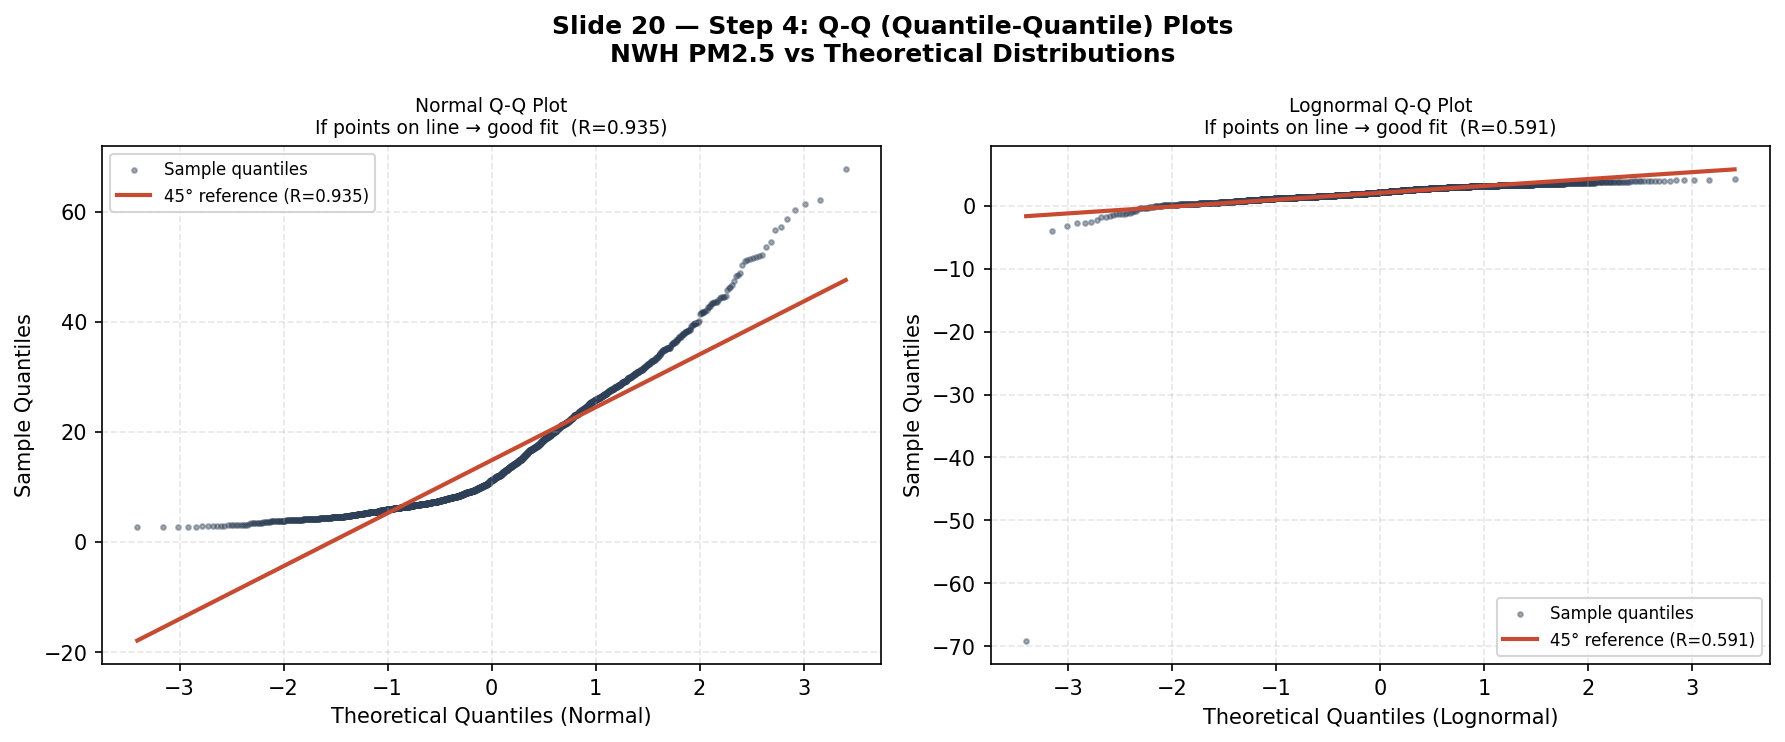

  ✅ Slide 20 saved


In [ ]:
print("Plotting Slide 20: Step 4 Q-Q Plot …")
fig, axes = plt.subplots(1, 2, figsize=(12,5), dpi=150)
fig.suptitle("Slide 20 — Step 4: Q-Q (Quantile-Quantile) Plots\nNWH PM2.5 vs Theoretical Distributions",
             fontsize=12, fontweight="bold")

for ax, (dist_name, dist_obj) in zip(axes, [("Normal", norm), ("Lognormal", lognorm)]):
    if dist_name == "Normal":
        (osm, osr), (slope, intercept, r) = stats.probplot(data_flat, dist="norm")
    else:
        (osm, osr), (slope, intercept, r) = stats.probplot(np.log(data_flat - data_flat.min()+1e-30), dist="norm")
    ax.scatter(osm, osr, s=5, alpha=0.4, color=COLORS["primary"], label="Sample quantiles")
    mn, mx = min(osm), max(osm)
    ax.plot([mn,mx],[slope*mn+intercept, slope*mx+intercept],
            color=COLORS["accent"], linewidth=2, label=f"45° reference (R={r:.3f})")
    ax.set_xlabel(f"Theoretical Quantiles ({dist_name})", fontsize=10)
    ax.set_ylabel("Sample Quantiles", fontsize=10)
    ax.set_title(f"{dist_name} Q-Q Plot\nIf points on line → good fit  (R={r:.3f})", fontsize=9)
    ax.legend(fontsize=8); ax.grid(True,linestyle="--",alpha=0.3)

fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR,"Slide20_Step4_QQ_Plot.png"), dpi=150, bbox_inches="tight")
plt.show()
print("  ✅ Slide 20 saved")


## Slide 21 — Step 5: Distribution Fitting Comparison (SSE)

Plotting Slide 21: Step 5 fitter comparison …


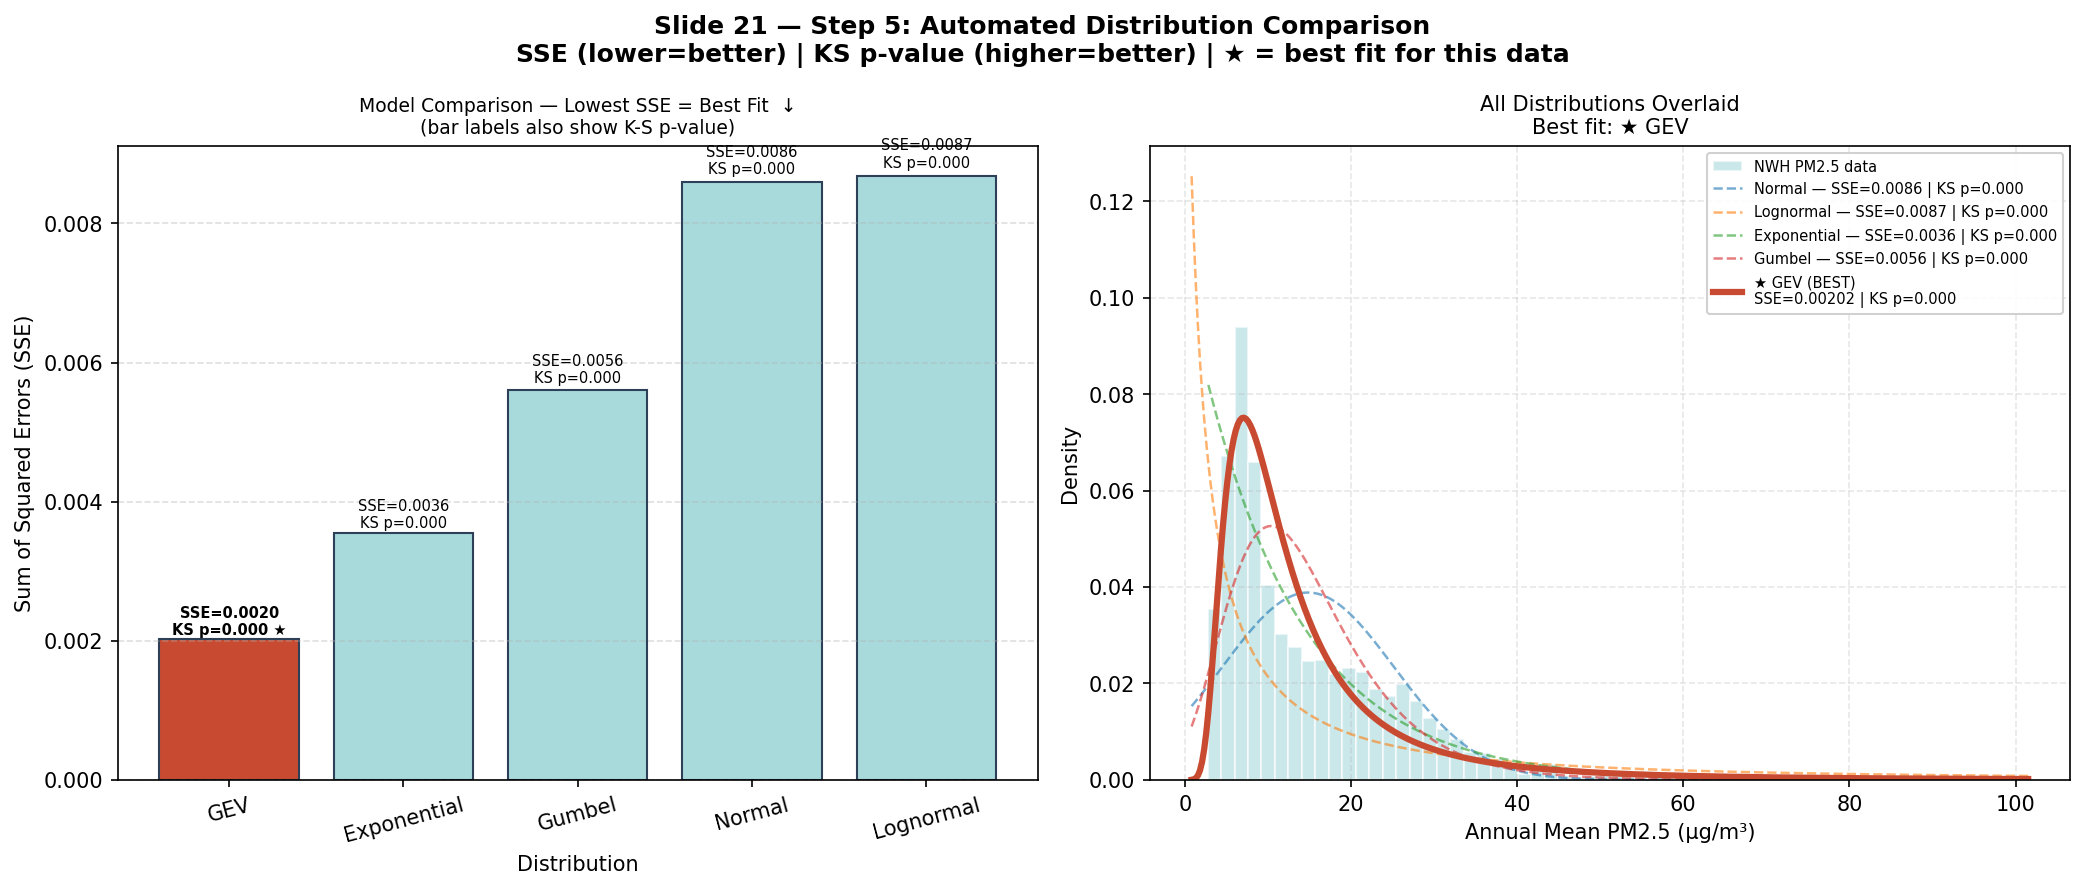

  ✅ Slide 21 saved

Full Ranking (best → worst):
  1. GEV: SSE=0.00202, KS p=0.000 ← BEST FIT
  2. Exponential: SSE=0.00355, KS p=0.000
  3. Gumbel: SSE=0.00561, KS p=0.000
  4. Normal: SSE=0.00859, KS p=0.000
  5. Lognormal: SSE=0.00868, KS p=0.000


In [ ]:
def _fit_stats(data, dist, params, shift=False):
    """Return (SSE, ks_pval) for a fitted distribution vs histogram."""
    hist_y, bin_edges = np.histogram(data, bins=40, density=True)
    bin_c = (bin_edges[:-1] + bin_edges[1:]) / 2
    try:
        if shift:
            pdf_v = dist.pdf(bin_c - data.min(), *params)
            ks_stat, ks_p = kstest(data - data.min(), dist.cdf, args=params)
        else:
            pdf_v = dist.pdf(bin_c, *params)
            ks_stat, ks_p = kstest(data, dist.cdf, args=params)
        sse = float(np.sum((hist_y - pdf_v)**2))
        return round(sse, 5), round(float(ks_p), 4)
    except Exception:
        return np.nan, np.nan

print("Plotting Slide 21: Step 5 fitter comparison …")
d_pos = data_flat - data_flat.min() + 1e-30

candidate_dists = {
    "Normal":      (norm,       norm.fit(data_flat),                        False),
    "Lognormal":   (lognorm,    lognorm.fit(d_pos, floc=0),                 False),
    "Exponential": (expon,      expon.fit(data_flat-data_flat.min(), floc=0), True),
    "Gumbel":      (gumbel_r,   gumbel_r.fit(data_flat),                    False),
    "GEV":         (genextreme, genextreme.fit(data_flat),                   False),
}

sse_list, ksp_list = [], []
for name, (dist, params, shift) in candidate_dists.items():
    sse, ksp = _fit_stats(data_flat, dist, params, shift=shift)
    sse_list.append((name, sse, ksp))

sse_list.sort(key=lambda x: x[1] if not np.isnan(x[1]) else 9999)
names_s  = [x[0] for x in sse_list]
sse_s    = [x[1] for x in sse_list]
ksp_s    = [x[2] for x in sse_list]
best_name = names_s[0]
colors_bar = [COLORS["accent"] if i==0 else COLORS["soft"] for i in range(len(names_s))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6), dpi=150)
fig.suptitle("Slide 21 — Step 5: Automated Distribution Comparison\n"
             "SSE (lower=better) | KS p-value (higher=better) | ★ = best fit for this data",
             fontsize=12, fontweight="bold")

# Bar chart with KS p-value annotated
bars = ax1.bar(names_s, sse_s, color=colors_bar, edgecolor=COLORS["primary"])
for bar, val, ksp, nm in zip(bars, sse_s, ksp_s, names_s):
    star = " ★" if nm == best_name else ""
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
             f"SSE={val:.4f}\nKS p={ksp:.3f}{star}",
             ha="center", va="bottom", fontsize=7, fontweight="bold" if nm==best_name else "normal")
ax1.set_xlabel("Distribution"); ax1.set_ylabel("Sum of Squared Errors (SSE)")
ax1.set_title("Model Comparison — Lowest SSE = Best Fit  ↓\n(bar labels also show K-S p-value)", fontsize=9)
ax1.grid(True, axis="y", linestyle="--", alpha=0.4)
ax1.tick_params(axis="x", rotation=15)

# Best fit overlaid
best_dist, best_params, best_shift = candidate_dists[best_name]
ax2.hist(data_flat, bins=40, density=True, color=COLORS["soft"],
         edgecolor="white", alpha=0.6, label="NWH PM2.5 data")
xs = np.linspace(data_flat.min()*0.3, data_flat.max()*1.5, 400)
# Also overlay all others faintly
for name, (dist, params, shift) in candidate_dists.items():
    try:
        ys = expon.pdf(xs-data_flat.min(),*params) if name=="Exponential" else dist.pdf(xs,*params)
        ys = np.where(np.isfinite(ys)&(ys>0), ys, np.nan)
        sse_v = next(x[1] for x in sse_list if x[0]==name)
        ksp_v = next(x[2] for x in sse_list if x[0]==name)
        if name == best_name:
            ax2.plot(xs, ys, color=COLORS["accent"], linewidth=3,
                     label=f"★ {name} (BEST)\nSSE={sse_v:.5f} | KS p={ksp_v:.3f}")
        else:
            ax2.plot(xs, ys, linewidth=1.2, linestyle="--", alpha=0.6,
                     label=f"{name} — SSE={sse_v:.4f} | KS p={ksp_v:.3f}")
    except: pass

ax2.set_xlabel("Annual Mean PM2.5 (µg/m³)"); ax2.set_ylabel("Density")
ax2.set_title(f"All Distributions Overlaid\nBest fit: ★ {best_name}", fontsize=10)
ax2.legend(fontsize=7, loc="upper right", framealpha=0.9)
ax2.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR,"Slide21_Step5_Fitter_Comparison.png"), dpi=150, bbox_inches="tight")
plt.show()
print("  ✅ Slide 21 saved")
print("\nFull Ranking (best → worst):")
for i, (nm, sse, ksp) in enumerate(sse_list):
    flag = " ← BEST FIT" if i==0 else ""
    print(f"  {i+1}. {nm}: SSE={sse:.5f}, KS p={ksp:.3f}{flag}")


## Slide 22 — Predicting Extremes: Return Level & Return Period Curves

Plotting Slide 22: Return Level Curve …


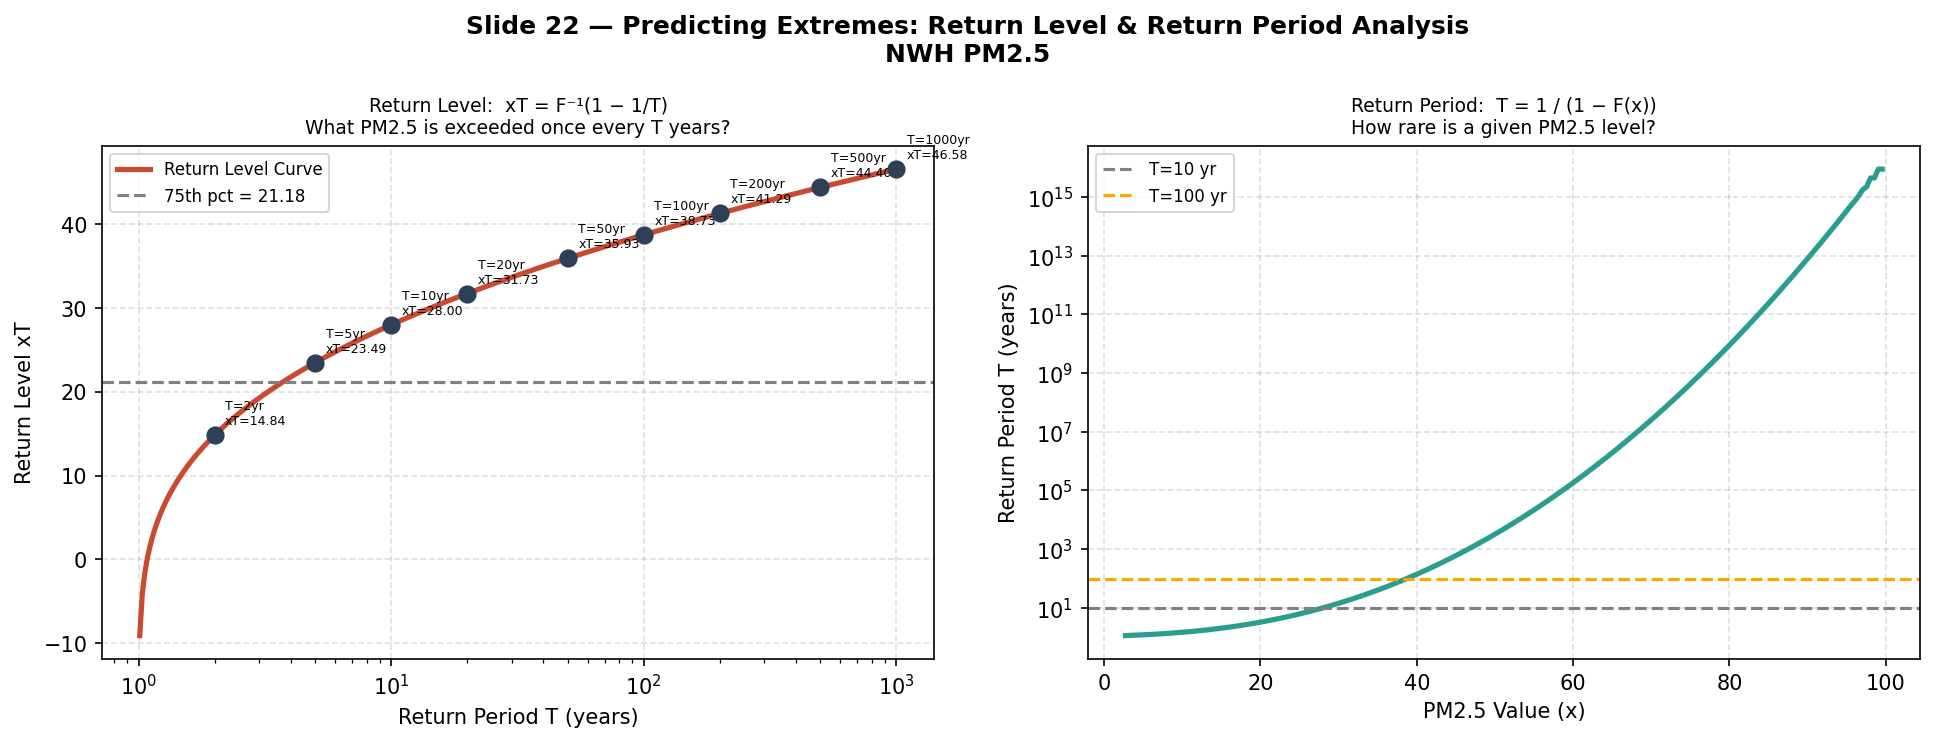

  ✅ Slide 22 saved


In [ ]:
print("Plotting Slide 22: Return Level Curve …")
mu_r, sigma_r = norm.fit(data_flat)
T_vals = np.array([2,5,10,20,50,100,200,500,1000])
return_levels = norm.ppf(1 - 1/T_vals, mu_r, sigma_r)

fig, (ax1,ax2) = plt.subplots(1,2, figsize=(13,5), dpi=150)
fig.suptitle("Slide 22 — Predicting Extremes: Return Level & Return Period Analysis\nNWH PM2.5",
             fontsize=12, fontweight="bold")

T_cont = np.logspace(np.log10(1.01), 3, 300)
RL_cont = norm.ppf(1-1/T_cont, mu_r, sigma_r)
ax1.semilogx(T_cont, RL_cont, color=COLORS["accent"], linewidth=2.5, label="Return Level Curve")
ax1.scatter(T_vals, return_levels, color=COLORS["primary"], s=60, zorder=5)
for T, RL in zip(T_vals, return_levels):
    ax1.annotate(f"T={T}yr\nxT={RL:.2f}", (T,RL), textcoords="offset points",
                 xytext=(5,5), fontsize=6)
ax1.axhline(threshold, color="grey", linestyle="--", label=f"75th pct = {threshold:.2f}")
ax1.set_xlabel("Return Period T (years)"); ax1.set_ylabel("Return Level xT")
ax1.set_title("Return Level:  xT = F⁻¹(1 − 1/T)\nWhat PM2.5 is exceeded once every T years?", fontsize=9)
ax1.legend(fontsize=8); ax1.grid(True,linestyle="--",alpha=0.4)

pm25_vals = np.linspace(data_flat.min(), data_flat.max()*1.5, 200)
T_curve   = 1/(1-norm.cdf(pm25_vals, mu_r, sigma_r))
T_curve   = np.where(np.isfinite(T_curve)&(T_curve>0), T_curve, np.nan)
ax2.semilogy(pm25_vals, T_curve, color=COLORS["green"], linewidth=2.5)
ax2.axhline(10, color="grey",linestyle="--",label="T=10 yr"); ax2.axhline(100, color="orange",linestyle="--",label="T=100 yr")
ax2.set_xlabel("PM2.5 Value (x)"); ax2.set_ylabel("Return Period T (years)")
ax2.set_title("Return Period:  T = 1 / (1 − F(x))\nHow rare is a given PM2.5 level?", fontsize=9)
ax2.legend(fontsize=8); ax2.grid(True,linestyle="--",alpha=0.4)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR,"Slide22_Return_Level_Curve.png"), dpi=150, bbox_inches="tight")
plt.show()
print("  ✅ Slide 22 saved")


## Slide 23 — Return Level Example (50-Year)

Plotting Slide 23: Return Level Example …


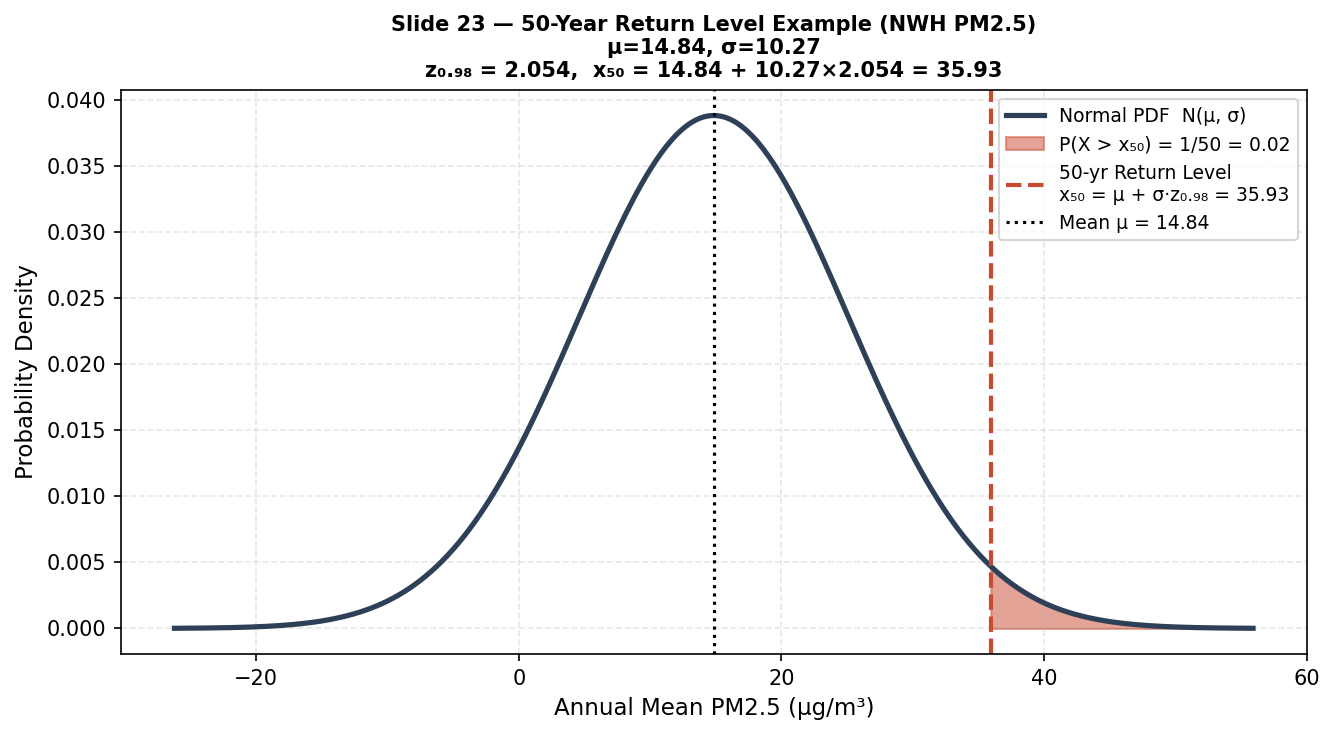

  ✅ Slide 23 saved


In [ ]:
print("Plotting Slide 23: Return Level Example …")
mu_r, sigma_r = norm.fit(data_flat)
T50  = 50
zT   = norm.ppf(1 - 1/T50)
x50  = mu_r + sigma_r * zT

fig, ax = plt.subplots(figsize=(9,5), dpi=150)
xs  = np.linspace(mu_r - 4*sigma_r, mu_r + 4*sigma_r, 400)
ys  = norm.pdf(xs, mu_r, sigma_r)
ax.plot(xs, ys, color=COLORS["primary"], linewidth=2.5, label="Normal PDF  N(μ, σ)")
ax.fill_between(xs, ys, where=(xs>=x50), color=COLORS["accent"], alpha=0.5,
                label=f"P(X > x₅₀) = 1/50 = 0.02")
ax.axvline(x50, color=COLORS["accent"], linestyle="--", linewidth=2,
           label=f"50-yr Return Level\nx₅₀ = μ + σ·z₀.₉₈ = {x50:.2f}")
ax.axvline(mu_r, color="black", linestyle=":", linewidth=1.5, label=f"Mean μ = {mu_r:.2f}")
ax.set_xlabel("Annual Mean PM2.5 (µg/m³)", fontsize=11)
ax.set_ylabel("Probability Density", fontsize=11)
ax.set_title(f"Slide 23 — 50-Year Return Level Example (NWH PM2.5)\n"
             f"μ={mu_r:.2f}, σ={sigma_r:.2f}\n"
             f"z₀.₉₈ = {zT:.3f},  x₅₀ = {mu_r:.2f} + {sigma_r:.2f}×{zT:.3f} = {x50:.2f}",
             fontsize=10, fontweight="bold")
ax.legend(fontsize=9); ax.grid(True,linestyle="--",alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR,"Slide23_Return_Level_Example.png"), dpi=150, bbox_inches="tight")
plt.show()
print("  ✅ Slide 23 saved")


## Slide 25 — Universal Key: CDF + Inverse CDF Panel

Plotting Slide 25: Universal Key — Inverse CDF …


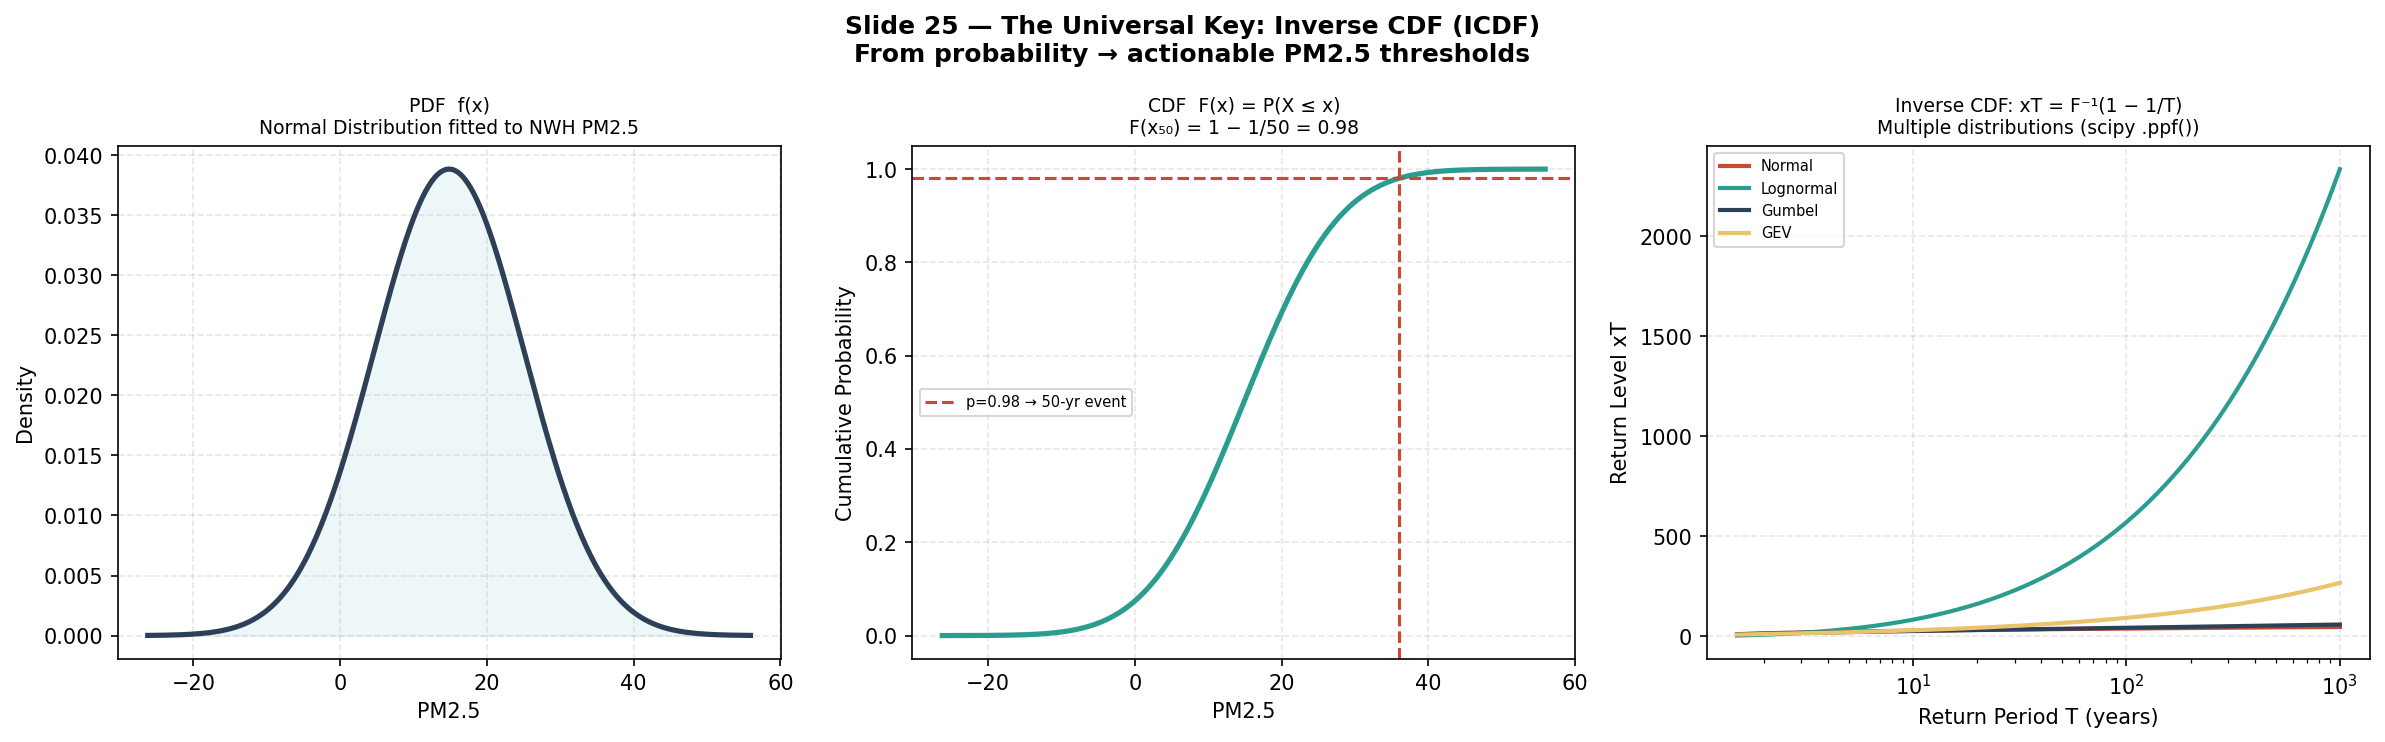

  ✅ Slide 25 saved


In [ ]:
print("Plotting Slide 25: Universal Key — Inverse CDF …")
mu_r, sigma_r = norm.fit(data_flat)
xs = np.linspace(mu_r-4*sigma_r, mu_r+4*sigma_r, 400)
probs = np.linspace(0.001, 0.999, 400)
d_pos = data_flat - data_flat.min() + 1e-30

fig, axes = plt.subplots(1,3, figsize=(16,5), dpi=150)
fig.suptitle("Slide 25 — The Universal Key: Inverse CDF (ICDF)\n"
             "From probability → actionable PM2.5 thresholds",
             fontsize=12, fontweight="bold")

# PDF
ax = axes[0]
ax.plot(xs, norm.pdf(xs,mu_r,sigma_r), color=COLORS["primary"], linewidth=2.5)
ax.fill_between(xs, norm.pdf(xs,mu_r,sigma_r), alpha=0.2, color=COLORS["soft"])
ax.set_title("PDF  f(x)\nNormal Distribution fitted to NWH PM2.5", fontsize=9)
ax.set_xlabel("PM2.5"); ax.set_ylabel("Density"); ax.grid(True,linestyle="--",alpha=0.3)

# CDF
ax = axes[1]
ax.plot(xs, norm.cdf(xs,mu_r,sigma_r), color=COLORS["green"], linewidth=2.5)
ax.axhline(0.98, color=COLORS["accent"],linestyle="--",label="p=0.98 → 50-yr event")
ax.axvline(norm.ppf(0.98,mu_r,sigma_r), color=COLORS["accent"],linestyle="--")
ax.set_title("CDF  F(x) = P(X ≤ x)\nF(x₅₀) = 1 − 1/50 = 0.98", fontsize=9)
ax.set_xlabel("PM2.5"); ax.set_ylabel("Cumulative Probability"); ax.legend(fontsize=7)
ax.grid(True,linestyle="--",alpha=0.3)

# Inverse CDF (PPF)
ax = axes[2]
dist_table = [
    ("Normal",   norm,        norm.fit(data_flat),          COLORS["accent"]),
    ("Lognormal",lognorm,     lognorm.fit(d_pos,floc=0),    COLORS["green"]),
    ("Gumbel",   gumbel_r,    gumbel_r.fit(data_flat),      COLORS["primary"]),
    ("GEV",      genextreme,  genextreme.fit(data_flat),     COLORS["gold"]),
]
T_plot = np.logspace(np.log10(1.5), 3, 200)
for name, dist, params, col in dist_table:
    try:
        RL = dist.ppf(1-1/T_plot, *params)
        RL = np.where(np.isfinite(RL), RL, np.nan)
        ax.semilogx(T_plot, RL, linewidth=2, color=col, label=name)
    except: pass
ax.set_xlabel("Return Period T (years)"); ax.set_ylabel("Return Level xT")
ax.set_title("Inverse CDF: xT = F⁻¹(1 − 1/T)\nMultiple distributions (scipy .ppf())", fontsize=9)
ax.legend(fontsize=7); ax.grid(True,linestyle="--",alpha=0.3)

fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR,"Slide25_Universal_Key_InverseCDF.png"), dpi=150, bbox_inches="tight")
plt.show()
print("  ✅ Slide 25 saved")
